<a href="https://colab.research.google.com/github/saiDan77/nn-from-scratch/blob/main/MLP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Manual Neural Network Implementation: A Step-by-Step Guide

This notebook serves as an illustrative guide to understanding the fundamental concepts behind neural networks by manually implementing a simple feedforward network.

## Purpose:

The primary goal of this notebook is to provide a granular, step-by-step walkthrough of how a neural network processes information, from raw inputs to a final prediction. We will explore:

1.  **Core Components:** Understanding activation functions (ReLU, Sigmoid, Tanh, Leaky ReLU, Linear, ELU, Softplus), the neuron's computation (weighted sum + bias), and their roles.
2.  **Forward Pass Mechanics:** Visualizing how input data propagates through a network, layer by layer, calculating pre-activations (`z`) and subsequent activations.
3.  **Weight and Bias Impact:** Demonstrating how changes in network parameters (weights and biases) affect the network's output.
4.  **Gradient Calculation (for `w11`):** A simplified look at how gradients are derived using the chain rule, which is foundational for learning algorithms like gradient descent.
5.  **Gradient Descent Simulation:** Observing a single step of gradient descent to understand how weights are adjusted to optimize predictions.
6.  **Generic Network Architectures:** Refactoring the implementation to support arbitrary numbers of hidden layers and custom activation functions, culminating in a `NeuralNetwork` class.
7.  **Parameter Persistence:** Implementing methods to save and load network parameters, enabling the reuse of trained models.

## Structure:

Each section of this notebook builds upon the previous one, gradually introducing complexity and abstraction. We start with basic, hardcoded examples and progress towards a more generalized and flexible neural network framework. Visualizations are integrated to intuitively explain abstract concepts.

This cell initiates our manual neural network construction by defining fundamental building blocks:
*   **Activation Functions:** `relu(x)` (Rectified Linear Unit) and `sigmoid(x)` are introduced, critical for introducing non-linearity into the network.
    *   `ReLU(x) = max(0, x)`
    *   `Sigmoid(x) = 1 / (1 + e^(-x))`
*   **Neuron Function:** The `neuron(inputs, weights, bias)` function encapsulates the core computation of a single neuron: the weighted sum of inputs plus a bias term, `z = sum(input_i * weight_i) + bias`. This `z` value is the *pre-activation*.
*   **Forward Pass Demonstration:** A simple 2-layer neural network (one hidden layer, one output layer) is manually constructed with hardcoded weights and biases. The code then meticulously computes the pre-activation (`z`) and activation values for each neuron in the hidden layer and the final output neuron, demonstrating how data flows through the network in a 'forward' direction.

In [ ]:
import math

def relu(x):
    """
    Rectified Linear Unit (ReLU) activation function.

    Mathematically: f(x) = max(0, x)

    Args:
        x (float): The input value.

    Returns:
        float: The activated output. Returns x if x > 0, otherwise 0.
    """
    return max(0, x)

def sigmoid(x):
    """
    Sigmoid activation function.

    Mathematically: f(x) = 1 / (1 + e^(-x))

    This function squashes its input into a range between 0 and 1, making it suitable
    for binary classification problems as an output activation.

    Args:
        x (float): The input value.

    Returns:
        float: The activated output, a value between 0 and 1.
    """
    return 1 / (1 + math.exp(-x))

def neuron(inputs, weights, bias):
    """
    Calculates the pre-activation (z-value) for a single neuron.

    Mathematically: z = sum(input_i * weight_i) + bias

    This function performs the core operation of a neuron: taking a weighted sum
    of its inputs and adding a bias term. This 'z' value is then typically passed
    through an activation function.

    Args:
        inputs (list): A list of numerical input values to the neuron.
        weights (list): A list of numerical weight values, corresponding to each input.
                        Must have the same length as `inputs`.
        bias (float): The bias term for the neuron.

    Returns:
        float: The pre-activation value (z) of the neuron.
    """
    # Calculate the weighted sum of inputs plus bias
    z = sum(i * w for i, w in zip(inputs, weights)) + bias
    return z

# Given Inputs
x1 = 2
x2 = 3

# Hidden layer weights and biases
# h1
w11 = 1
w12 = 2
b1 = 1

# h2
w21 = -1
w22 = 3
b2 = 0

# Output layer weights and bias
wo1 = 1
wo2 = 0.5
bo = -2

# --- Compute Hidden Layer ---

# Compute h1
h1_inputs = [x1, x2]
h1_weights = [w11, w12]
z1 = neuron(h1_inputs, h1_weights, b1)
h1_activation = relu(z1)
print(f"Hidden neuron 1 z = {z1}")
print(f"Hidden neuron 1 activation = {h1_activation}")

print("\n")

# Compute h2
h2_inputs = [x1, x2]
h2_weights = [w21, w22]
z2 = neuron(h2_inputs, h2_weights, b2)
h2_activation = relu(z2)
print(f"Hidden neuron 2 z = {z2}")
print(f"Hidden neuron 2 activation = {h2_activation}")

print("\n")

# --- Compute Output Layer ---

# Compute output neuron
output_inputs = [h1_activation, h2_activation]
output_weights = [wo1, wo2]
z_output = neuron(output_inputs, output_weights, bo)
prediction = sigmoid(z_output)

print(f"Output z = {z_output}")
print(f"Prediction = {prediction}")

Hidden neuron 1 z = 9
Hidden neuron 1 activation = 9


Hidden neuron 2 z = 7
Hidden neuron 2 activation = 7


Output z = 10.5
Prediction = 0.9999724643088853


### Derivatives of Activation Functions

To calculate the gradients, we need the derivatives of our activation functions:

To enable the network to learn, we need to adjust its weights and biases based on the error in its predictions. This adjustment process, known as backpropagation, relies heavily on the *derivatives* of the activation functions. This cell defines these crucial derivative functions:
*   **`d_relu(x)`:** The derivative of the ReLU function.
    *   `d/dx ReLU(x) = 1` if `x > 0`, and `0` otherwise.
*   **`d_sigmoid(x)`:** The derivative of the Sigmoid function.
    *   `d/dx Sigmoid(x) = Sigmoid(x) * (1 - Sigmoid(x))`
These functions will be essential later when we calculate gradients to update network parameters.

In [ ]:
# Derivative of ReLU
def d_relu(x):
    return 1 if x > 0 else 0

# Derivative of Sigmoid
def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

print("Derivative functions for ReLU and Sigmoid defined.")

Derivative functions for ReLU and Sigmoid defined.


### Calculating the Gradient of Prediction with Respect to `w11`

Now, let's calculate `d(prediction) / d(w11)` using the chain rule. The formula is:

`d(prediction)/d(w11) = d(prediction)/d(z_output) * d(z_output)/d(h1_activation) * d(h1_activation)/d(z1) * d(z1)/d(w11)`

Broken down:
*   `d(prediction)/d(z_output)` is `d_sigmoid(z_output)`
*   `d(z_output)/d(h1_activation)` is `wo1` (since `h2_activation * wo2 + bo` is constant with respect to `h1_activation`)
*   `d(h1_activation)/d(z1)` is `d_relu(z1)`
*   `d(z1)/d(w11)` is `x1` (since `x2 * w12 + b1` is constant with respect to `w11`)

So, `d(prediction)/d(w11) = d_sigmoid(z_output) * wo1 * d_relu(z1) * x1`

This cell introduces the `calculate_gradient_w11` function, which is a core component of backpropagation. Its purpose is to compute the *gradient* of the final prediction with respect to a specific weight, `w11` (the weight connecting input `x1` to hidden neuron `h1`).

The function operates by:
1.  Performing a complete `run_forward_pass` to obtain all intermediate `z` (pre-activation) and activation values.
2.  Applying the **Chain Rule** of calculus, utilizing the `d_sigmoid` and `d_relu` derivative functions, to meticulously compute how a tiny change in `w11` affects the final prediction.

The gradient `d(prediction)/d(w11)` indicates both the magnitude and direction of the steepest ascent of the prediction surface concerning `w11`. This value is then tested with the original network parameters to demonstrate its calculation.

In [ ]:
def calculate_gradient_w11(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo):
    # Perform a forward pass to get all intermediate values
    forward_results = run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
    z1 = forward_results['z1']
    z_output = forward_results['z_output']

    # Calculate individual gradients using our derivative functions
    grad_sigmoid_z_output = d_sigmoid(z_output)
    grad_z_output_h1_activation = wo1
    grad_h1_activation_z1 = d_relu(z1)
    grad_z1_w11 = x1

    # Apply the chain rule
    gradient = grad_sigmoid_z_output * grad_z_output_h1_activation * grad_h1_activation_z1 * grad_z1_w11
    return gradient

# Test with original values
original_gradient_w11 = calculate_gradient_w11(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
print(f"Gradient of prediction with respect to w11 (original values): {original_gradient_w11}")

Gradient of prediction with respect to w11 (original values): 5.506986580080658e-05


### Visualizing the Gradient of `w11`

Let's now plot how the gradient `d(prediction) / d(w11)` changes as `w11` varies. This will highlight the regions where changes in `w11` have the most significant impact on the final prediction.

This cell provides a crucial visualization of the gradient's behavior. It iteratively calculates `d(prediction)/d(w11)` across a wide range of `w11` values. The resulting plot, generated using `matplotlib` and `seaborn`, clearly illustrates:
*   **Gradient Magnitude:** Where changes in `w11` lead to the most significant (steepest) changes in the prediction.
*   **Gradient Direction:** The slope of the gradient curve indicates whether increasing `w11` increases or decreases the prediction.
Understanding this curve is fundamental for grasping how gradient-based optimization algorithms (like gradient descent) operate to find optimal weight values.

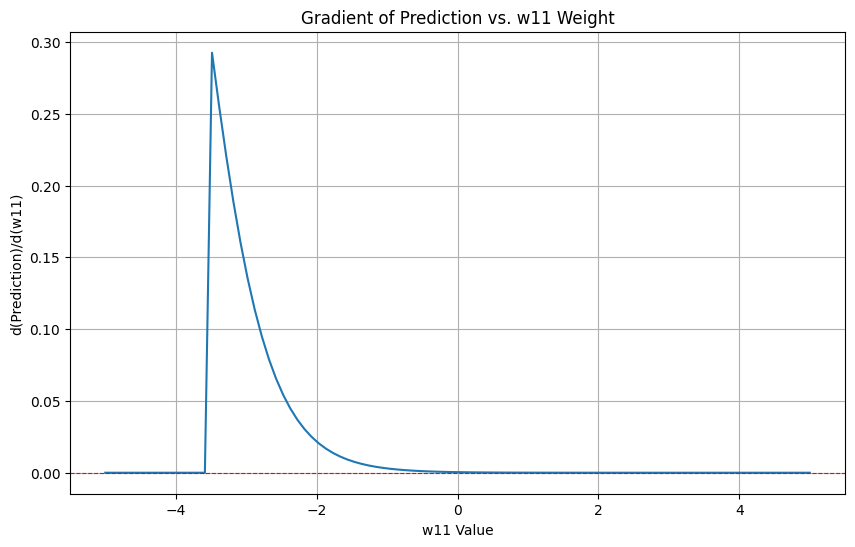

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the range for w11 (same as before)
w11_values_for_gradient = np.linspace(-5, 5, 100)

# List to store gradients
gradients_w11 = []

# Iterate through each w11 value and calculate the gradient
for current_w11 in w11_values_for_gradient:
    gradient = calculate_gradient_w11(
        x1, x2,
        current_w11, w12, b1, # w11 is varied, others constant
        w21, w22, b2,
        wo1, wo2, bo
    )
    gradients_w11.append(gradient)

plt.figure(figsize=(10, 6))
sns.lineplot(x=w11_values_for_gradient, y=gradients_w11)
plt.title('Gradient of Prediction vs. w11 Weight')
plt.xlabel('w11 Value')
plt.ylabel('d(Prediction)/d(w11)')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a line at y=0
plt.show()

### Simulating a Gradient Descent Update for `w11`

Now let's apply a single step of gradient descent to `w11` using a chosen learning rate to see its effect.

This cell concretely demonstrates a single iteration of **Gradient Descent**, a cornerstone optimization algorithm in neural networks.
1.  **Gradient Calculation:** It first computes the current gradient of the prediction with respect to `w11` at its present value.
2.  **Weight Update:** Using a predefined `learning_rate` (a hyperparameter controlling the step size), `w11` is updated according to the formula:
    `new_w11 = old_w11 - (learning_rate * gradient)`
    The negative sign is crucial: we move in the opposite direction of the gradient to *minimize* an implicit loss (or maximize the prediction in this specific simplified example).
3.  **Impact Observation:** Finally, the cell shows the `prediction` before and after this single update, illustrating how the network's output begins to change in response to the weight adjustment, guided by the gradient.

In [ ]:
def run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo):
    """Runs a complete forward pass through the network and returns the final prediction and intermediate values."""

    # Compute h1
    h1_inputs = [x1, x2]
    h1_weights = [w11, w12]
    z1 = neuron(h1_inputs, h1_weights, b1)
    h1_activation = relu(z1)

    # Compute h2
    h2_inputs = [x1, x2]
    h2_weights = [w21, w22]
    z2 = neuron(h2_inputs, h2_weights, b2)
    h2_activation = relu(z2)

    # Compute output neuron
    output_inputs = [h1_activation, h2_activation]
    output_weights = [wo1, wo2]
    z_output = neuron(output_inputs, output_weights, bo)
    prediction = sigmoid(z_output)

    return {
        'z1': z1,
        'h1_activation': h1_activation,
        'z2': z2,
        'h2_activation': h2_activation,
        'z_output': z_output,
        'prediction': prediction
    }

# Demonstrate using the original weights and biases
original_results = run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
print(f"Original prediction using run_forward_pass: {original_results['prediction']}")
print(f"Original h1_activation: {original_results['h1_activation']}")
print(f"Original h2_activation: {original_results['h2_activation']}")

Original prediction using run_forward_pass: 0.9999724643088853
Original h1_activation: 9
Original h2_activation: 7


In [ ]:
# Define a learning rate
learning_rate = 0.1

# Get the current w11 and its gradient
old_w11 = w11 # Using the global w11 variable from setup
gradient_at_old_w11 = calculate_gradient_w11(x1, x2, old_w11, w12, b1, w21, w22, b2, wo1, wo2, bo)

# Perform the gradient descent update
new_w11 = old_w11 - (learning_rate * gradient_at_old_w11)

# Calculate predictions before and after the update
old_prediction_results = run_forward_pass(x1, x2, old_w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
old_prediction = old_prediction_results['prediction']

new_prediction_results = run_forward_pass(x1, x2, new_w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
new_prediction = new_prediction_results['prediction']

print(f"Initial w11: {old_w11}")
print(f"Gradient at initial w11: {gradient_at_old_w11}")
print(f"Learning Rate: {learning_rate}")
print(f"Calculated new w11: {new_w11}")
print(f"\nPrediction with old w11: {old_prediction}")
print(f"Prediction with new w11: {new_prediction}")


Initial w11: 1
Gradient at initial w11: 5.506986580080658e-05
Learning Rate: 0.1
Calculated new w11: 0.9999944930134199

Prediction with old w11: 0.9999724643088853
Prediction with new w11: 0.9999724640056147


### Step-by-step Value Progression for Different `w11` and `w12` Combinations

The `print_forward_pass_details` function is introduced here to offer an exhaustive, neuron-level breakdown of the forward pass. For a specified set of input `x1`, `x2`, and network parameters, it explicitly shows:
*   The `z` (pre-activation) calculation for each neuron: `z = sum(input_i * weight_i) + bias`.
*   The application of the activation function (`relu` or `sigmoid`) to obtain the neuron's output.
This function is then utilized to illustrate how systematic variations in `w11` and `w12` (the weights feeding into the first hidden neuron) propagate through the network, significantly altering both intermediate activations and the ultimate `prediction`. This reinforces the concept of how individual parameters influence the overall network behavior.

In [ ]:
def print_forward_pass_details(label, x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo):
    print(f"\n--- {label}: w11={w11}, w12={w12} ---")
    results = run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo)

    # Input layer
    print(f"Inputs: x1={x1}, x2={x2}")

    # Hidden layer 1
    print(f"\n--- Hidden Neuron 1 (h1) ---")
    print(f"  z1 = (x1 * w11) + (x2 * w12) + b1")
    print(f"     = ({x1} * {w11}) + ({x2} * {w12}) + {b1}")
    print(f"     = {results['z1']}")
    print(f"  h1_activation = relu(z1) = relu({results['z1']}) = {results['h1_activation']}")

    # Hidden layer 2 (unchanged in these examples, using original w21, w22, b2)
    print(f"\n--- Hidden Neuron 2 (h2) ---")
    print(f"  z2 = (x1 * w21) + (x2 * w22) + b2")
    print(f"     = ({x1} * {w21}) + ({x2} * {w22}) + {b2}")
    print(f"     = {results['z2']}")
    print(f"  h2_activation = relu(z2) = relu({results['z2']}) = {results['h2_activation']}")

    # Output layer
    print(f"\n--- Output Neuron ---")
    print(f"  Input to output layer: h1_activation={results['h1_activation']}, h2_activation={results['h2_activation']}")
    print(f"  z_output = (h1_activation * wo1) + (h2_activation * wo2) + bo")
    print(f"           = ({results['h1_activation']} * {wo1}) + ({results['h2_activation']} * {wo2}) + {bo}")
    print(f"           = {results['z_output']}")
    print(f"  Prediction = sigmoid(z_output) = sigmoid({results['z_output']}) = {results['prediction']}")


# Example 1: Low w11, Low w12 (expecting low prediction)
print_forward_pass_details("Case 1 (Low Prediction)", x1, x2, -4, -4, b1, w21, w22, b2, wo1, wo2, bo)

# Example 2: Mid-range w11, Mid-range w12 (expecting transition)
print_forward_pass_details("Case 2 (Transition)", x1, x2, 0, 0, b1, w21, w22, b2, wo1, wo2, bo)

# Example 3: High w11, High w12 (expecting high prediction - saturation)
print_forward_pass_details("Case 3 (High Prediction)", x1, x2, 4, 4, b1, w21, w22, b2, wo1, wo2, bo)



--- Case 1 (Low Prediction): w11=-4, w12=-4 ---
Inputs: x1=2, x2=3

--- Hidden Neuron 1 (h1) ---
  z1 = (x1 * w11) + (x2 * w12) + b1
     = (2 * -4) + (3 * -4) + 1
     = -19
  h1_activation = relu(z1) = relu(-19) = 0

--- Hidden Neuron 2 (h2) ---
  z2 = (x1 * w21) + (x2 * w22) + b2
     = (2 * -1) + (3 * 3) + 0
     = 7
  h2_activation = relu(z2) = relu(7) = 7

--- Output Neuron ---
  Input to output layer: h1_activation=0, h2_activation=7
  z_output = (h1_activation * wo1) + (h2_activation * wo2) + bo
           = (0 * 1) + (7 * 0.5) + -2
           = 1.5
  Prediction = sigmoid(z_output) = sigmoid(1.5) = 0.8175744761936437

--- Case 2 (Transition): w11=0, w12=0 ---
Inputs: x1=2, x2=3

--- Hidden Neuron 1 (h1) ---
  z1 = (x1 * w11) + (x2 * w12) + b1
     = (2 * 0) + (3 * 0) + 1
     = 1
  h1_activation = relu(z1) = relu(1) = 1

--- Hidden Neuron 2 (h2) ---
  z2 = (x1 * w21) + (x2 * w22) + b2
     = (2 * -1) + (3 * 3) + 0
     = 7
  h2_activation = relu(z2) = relu(7) = 7

--- Output N

In [ ]:
import numpy as np

# Define the range for w11
w11_values_to_test = np.linspace(-5, 5, 100) # 100 values from -5 to 5

# List to store predictions
predictions_for_w11_range = []

# Iterate through each w11 value and run the forward pass
for current_w11 in w11_values_to_test:
    prediction = run_forward_pass(
        x1, x2,
        current_w11, w12, b1, # w11 is varied
        w21, w22, b2,
        wo1, wo2, bo
    )
    predictions_for_w11_range.append(prediction)

# Display the first few and last few predictions
print("First 5 predictions:", predictions_for_w11_range[:5])
print("Last 5 predictions:", predictions_for_w11_range[-5:])


First 5 predictions: [0.8175744761936437, 0.8175744761936437, 0.8175744761936437, 0.8175744761936437, 0.8175744761936437]
Last 5 predictions: [0.9999999792748773, 0.9999999830659495, 0.9999999861635527, 0.9999999886945373, 0.9999999907625504]


This cell explores the effect of varying a single weight (`w11`) on the final prediction. It calculates predictions across a range of `w11` values and prints the first and last few predictions.

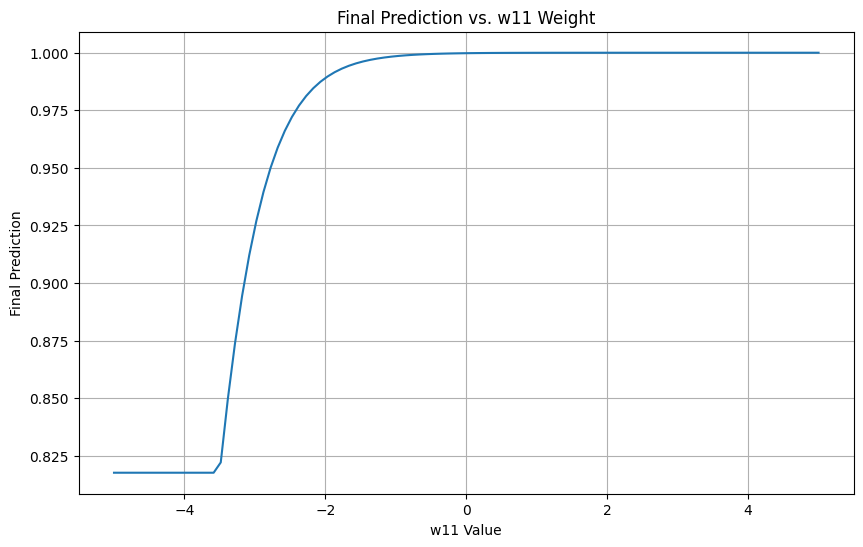

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x=w11_values_to_test, y=predictions_for_w11_range)
plt.title('Final Prediction vs. w11 Weight')
plt.xlabel('w11 Value')
plt.ylabel('Final Prediction')
plt.grid(True)
plt.show()

This cell visualizes the relationship between the `w11` weight and the final prediction. It plots the predictions calculated in the previous cell against the range of `w11` values, showing the sigmoid-like curve.

### Exploring the impact of varying both `w11` and `w12`

Moving beyond varying a single weight, this cell investigates the combined influence of two weights, `w11` and `w12`, on the network's final prediction.
1.  **Parameter Grid:** A 2D grid of possible `w11` and `w12` values is generated using `numpy.meshgrid`.
2.  **Exhaustive Forward Passes:** For every unique combination of `w11` and `w12` within this grid, a full `run_forward_pass` is executed.
3.  **Prediction Mapping:** The resulting predictions are systematically stored in a 2D array, creating a 'prediction landscape'. This data will be used in the next cell to visually represent how the network's output responds to simultaneous changes in these two key parameters, offering a glimpse into the multi-dimensional nature of neural network optimization.

In [ ]:
import numpy as np

# Define the ranges for w11 and w12
w11_range = np.linspace(-5, 5, 50)
w12_range = np.linspace(-5, 5, 50)

# Create a meshgrid for w11 and w12
W11, W12 = np.meshgrid(w11_range, w12_range)

# Initialize a 2D array to store predictions
predictions_2d = np.zeros(W11.shape)

# Iterate through each combination of w11 and w12
for i in range(W11.shape[0]):
    for j in range(W11.shape[1]):
        current_w11 = W11[i, j]
        current_w12 = W12[i, j]

        prediction = run_forward_pass(
            x1, x2,
            current_w11, current_w12, b1,
            w21, w22, b2,
            wo1, wo2, bo
        )
        predictions_2d[i, j] = prediction

print("Predictions generated for a grid of w11 and w12 values.")

Predictions generated for a grid of w11 and w12 values.


Building on the data generated in the previous cell, this visualization transforms the 2D array of predictions into a **Contour Plot**. This powerful graphical representation, generated using `matplotlib` and `seaborn`, depicts the 'prediction surface' in 3D (though rendered in 2D):
*   The X and Y axes represent the values of `w11` and `w12`.
*   The contour lines (and color gradients) represent different levels of the `final prediction`.
This plot offers intuitive insights into:
*   **Interaction Effects:** How `w11` and `w12` jointly influence the prediction.
*   **Regions of Stability/Sensitivity:** Areas where predictions are relatively flat or sharply changing.
*   **Potential Optimization Paths:** Visualizing the 'hills' and 'valleys' of the prediction surface, hinting at where gradient descent would guide the weights towards optimal solutions.

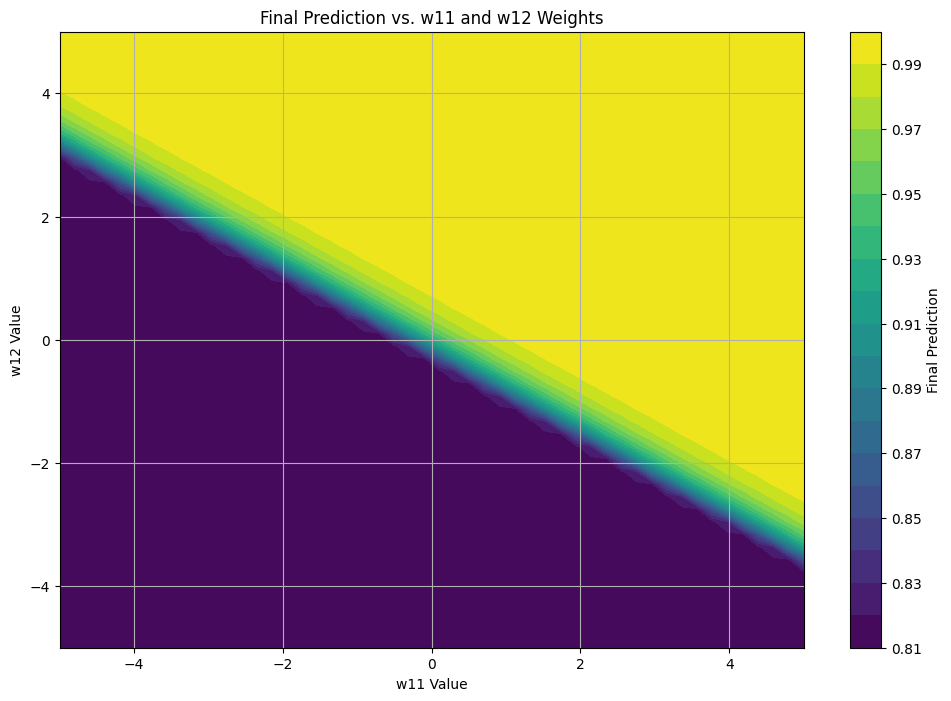

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
contour = plt.contourf(W11, W12, predictions_2d, levels=20, cmap='viridis')
plt.colorbar(contour, label='Final Prediction')
plt.title('Final Prediction vs. w11 and w12 Weights')
plt.xlabel('w11 Value')
plt.ylabel('w12 Value')
plt.grid(True)
plt.show()

### Refactoring for a Generic Network Architecture

This cell represents a pivotal step towards building a more flexible and scalable neural network. The `run_forward_pass_generic` function refactors the previous hardcoded, neuron-by-neuron calculations into a more abstract and reusable structure. This abstraction is crucial for handling networks with varying sizes and configurations without requiring extensive code modifications.

#### Key Enhancements:

*   **Abstracted Network Configuration:** Instead of individual `w` and `b` variables, the function now accepts structured configurations:
    *   `inputs`: The initial data vector provided to the network.
    *   `hidden_layer_config`: A list where each element is a tuple `(weights, bias)` for a neuron in the *single* hidden layer. For a hidden layer with `N` neurons, this list will contain `N` such tuples.
    *   `output_layer_config`: A single tuple `(weights, bias)` for the output neuron. The number of `weights` in this tuple must match the number of neurons in the preceding hidden layer.

*   **Dynamic Neuron Computation:** The function iterates through the `hidden_layer_config` to process each neuron. For each hidden neuron:
    1.  **Pre-activation (z-value):** The weighted sum of inputs plus bias is computed.
        $$z = \sum_{i=1}^{N_{inputs}} (input_i \cdot weight_i) + bias$$
        Where $N_{inputs}$ is the number of inputs to the current neuron.
    2.  **Activation:** The `relu` activation function is applied to the `z`-value.
        $$h_{activation} = ReLU(z) = \max(0, z)$$
    The outputs (activations) of these hidden neurons then become the inputs for the subsequent layer.

*   **Output Layer Processing:** The final output neuron receives inputs from the activations of the hidden layer, calculates its pre-activation `z_output`, and applies the `sigmoid` activation function to produce the final `prediction`.
    $$z_{output} = \sum_{j=1}^{N_{hidden}} (h_{j_{activation}} \cdot w_{o_j}) + b_o$$
    $$Prediction = Sigmoid(z_{output}) = \frac{1}{1 + e^{-z_{output}}}$$
    Where $N_{hidden}$ is the number of neurons in the hidden layer, $h_{j_{activation}}$ are the activations from the hidden layer, and $w_{o_j}$ and $b_o$ are the weights and bias for the output neuron.

The demonstration in the accompanying code verifies that this generic function, when supplied with the original network parameters, yields identical results to the initial hardcoded forward pass. This confirms the correctness of the refactoring and establishes a more robust foundation for building deeper and more complex neural networks.

In [ ]:
import math

# Helper functions (copied for self-contained exercise)
def relu(x):
    return max(0, x)

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def neuron(inputs, weights, bias):
    # Calculate the weighted sum of inputs plus bias
    z = sum(i * w for i, w in zip(inputs, weights)) + bias
    return z

# --- Generic run_forward_pass function ---
def run_forward_pass_generic(inputs, hidden_layer_config, output_layer_config):
    """Runs a complete forward pass through a generically structured network.

    Args:
        inputs (list): List of input values (e.g., [x1, x2]).
        hidden_layer_config (list): A list where each element is a tuple (weights, bias)
                                    for a hidden neuron (e.g., [([w11, w12], b1), ([w21, w22], b2)]).
        output_layer_config (tuple): A tuple (weights, bias) for the output neuron
                                     (e.g., ([wo1, wo2], bo)).

    Returns:
        dict: Contains final prediction and intermediate values.
    """

    current_inputs = inputs # Start with the network's initial inputs
    hidden_activations = []
    hidden_zs = []

    # Hidden Layer: Iterate through each hidden neuron's weights and bias
    for weights, bias in hidden_layer_config:
        z = neuron(current_inputs, weights, bias)
        h_activation = relu(z)
        hidden_zs.append(z)
        hidden_activations.append(h_activation)

    # The outputs of the hidden layer become inputs to the output layer
    output_inputs = hidden_activations

    # Output Layer
    output_weights, output_bias = output_layer_config
    z_output = neuron(output_inputs, output_weights, output_bias)
    prediction = sigmoid(z_output)

    # Return all intermediate values for potential gradient calculations
    return {
        'hidden_zs': hidden_zs, # List of z values for hidden neurons
        'hidden_activations': hidden_activations, # List of activations for hidden neurons
        'z_output': z_output,
        'prediction': prediction
    }

# --- Initial Setup (Generic) ---

# Given Inputs
x1_generic = 2
x2_generic = 3
network_inputs = [x1_generic, x2_generic]

# Define network architecture using the generic structure
# h1: weights [w11, w12], bias b1
# h2: weights [w21, w22], bias b2
# Output: weights [wo1, wo2], bias bo

# For this generic exercise, let's use the original values for demonstration
# Hidden layer weights and biases
w11_gen, w12_gen, b1_gen = 1, 2, 1
w21_gen, w22_gen, b2_gen = -1, 3, 0

# Output layer weights and bias
wo1_gen, wo2_gen, bo_gen = 1, 0.5, -2

hidden_layer_configuration = [
    ([w11_gen, w12_gen], b1_gen), # Config for Hidden Neuron 1
    ([w21_gen, w22_gen], b2_gen)  # Config for Hidden Neuron 2
]

output_layer_configuration = ([wo1_gen, wo2_gen], bo_gen)

# --- Perform Forward Pass using Generic Function ---
print('--- Initial Forward Pass (Generic Network Refactor) ---')
generic_results = run_forward_pass_generic(network_inputs, hidden_layer_configuration, output_layer_configuration)

# Print results using the generic results structure
print(f"Inputs: {network_inputs}")
print(f"Hidden Neuron 1 z = {generic_results['hidden_zs'][0]}")
print(f"Hidden Neuron 1 activation = {generic_results['hidden_activations'][0]}")
print(f"Hidden Neuron 2 z = {generic_results['hidden_zs'][1]}")
print(f"Hidden Neuron 2 activation = {generic_results['hidden_activations'][1]}")
print(f"Output z = {generic_results['z_output']}")
print(f"Prediction = {generic_results['prediction']}")


--- Initial Forward Pass (Generic Network Refactor) ---
Inputs: [2, 3]
Hidden Neuron 1 z = 9
Hidden Neuron 1 activation = 9
Hidden Neuron 2 z = 7
Hidden Neuron 2 activation = 7
Output z = 10.5
Prediction = 0.9999724643088853


### Generic Network with Arbitrary Number of Hidden Layers

To make the network even more flexible, we'll modify the `run_forward_pass_generic` function to accept a list of hidden layers, allowing for any number of hidden layers.

Building upon the previous generic implementation, this cell introduces `run_forward_pass_multi_layer_generic`, which dramatically increases the network's flexibility by supporting an **arbitrary number of hidden layers**.
*   The `hidden_layers_config` parameter is now a *list of lists*, where each inner list represents a hidden layer and contains `(weights, bias)` tuples for its neurons.
The demonstration configures a network with *two hidden layers* (a 3-layer network overall, including the output). It then performs a forward pass through this deeper architecture, printing the `z` values and activations for each neuron in every layer. This showcases the power of abstraction, allowing for the construction and evaluation of more complex neural network topologies by simply modifying configuration parameters rather than the core logic.

In [ ]:
import math

# Helper functions (copied for self-contained exercise)
def relu(x):
    return max(0, x)

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def neuron(inputs, weights, bias):
    # Calculate the weighted sum of inputs plus bias
    z = sum(i * w for i, w in zip(inputs, weights)) + bias
    return z

# --- Updated run_forward_pass_generic for arbitrary hidden layers ---
def run_forward_pass_multi_layer_generic(inputs, hidden_layers_config, output_layer_config):
    """Runs a complete forward pass through a generically structured network with multiple hidden layers.

    Args:
        inputs (list): List of input values (e.g., [x1, x2]).
        hidden_layers_config (list): A list where each element represents a hidden layer.
                                     Each layer is itself a list of (weights, bias) tuples for its neurons.
                                     E.g., [
                                            [([w11_l1, w12_l1], b1_l1), ([w21_l1, w22_l1], b2_l1)], # Layer 1
                                            [([w11_l2], b1_l2)] # Layer 2
                                           ]
        output_layer_config (tuple): A tuple (weights, bias) for the output neuron.

    Returns:
        dict: Contains final prediction and intermediate values for all layers.
              'hidden_zs': list of lists, outer list for layers, inner for neuron pre-activations.
              'hidden_activations': list of lists, outer list for layers, inner for neuron activations.
    """

    all_hidden_activations = [] # Stores activations for each hidden layer
    all_hidden_zs = []          # Stores pre-activations (z values) for each hidden layer

    current_inputs = inputs # Start with the network's initial inputs

    # Iterate through each hidden layer
    for layer_index, layer_config in enumerate(hidden_layers_config):
        layer_activations = []
        layer_zs = []

        # Iterate through each neuron in the current hidden layer
        for neuron_index, (weights, bias) in enumerate(layer_config):
            z = neuron(current_inputs, weights, bias)
            h_activation = relu(z)
            layer_zs.append(z)
            layer_activations.append(h_activation)

        all_hidden_zs.append(layer_zs)
        all_hidden_activations.append(layer_activations)
        current_inputs = layer_activations # Output of current layer becomes input for the next layer

    # Output Layer: The inputs to the output layer are the activations of the last hidden layer
    output_weights, output_bias = output_layer_config
    z_output = neuron(current_inputs, output_weights, output_bias)
    prediction = sigmoid(z_output)

    return {
        'hidden_zs': all_hidden_zs,
        'hidden_activations': all_hidden_activations,
        'z_output': z_output,
        'prediction': prediction
    }

# --- Demonstrate with a network with two hidden layers ---

# Given Inputs
x1_multi_layer = 2
x2_multi_layer = 3
network_inputs_multi_layer = [x1_multi_layer, x2_multi_layer]

# Define weights and biases for a two-hidden-layer network
# Layer 1 (2 neurons, same as original h1, h2 structure)
w11_l1, w12_l1, b1_l1 = 1, 2, 1
w21_l1, w22_l1, b2_l1 = -1, 3, 0

# Layer 2 (1 neuron for simplicity)
w11_l2, b1_l2 = 0.5, -0.5 # Takes inputs from Layer 1 activations

# Output Layer (takes input from Layer 2 activations)
wo1_final, bo_final = 1, -2

hidden_layers_configuration = [
    [ # First Hidden Layer Configuration
        ([w11_l1, w12_l1], b1_l1), # Neuron 1 in Layer 1
        ([w21_l1, w22_l1], b2_l1)  # Neuron 2 in Layer 1
    ],
    [ # Second Hidden Layer Configuration
        ([w11_l2], b1_l2)          # Neuron 1 in Layer 2 (inputs are outputs of Layer 1)
    ]
]

output_layer_configuration_final = ([wo1_final], bo_final) # Note: output layer weights now match number of neurons in last hidden layer

print('--- Initial Forward Pass (Multi-Layer Generic Network) ---')
multi_layer_results = run_forward_pass_multi_layer_generic(network_inputs_multi_layer, hidden_layers_configuration, output_layer_configuration_final)

# Print results
print(f"Inputs: {network_inputs_multi_layer}")
print(f"\n--- Hidden Layer 1 ---")
print(f"  Neuron 1 z = {multi_layer_results['hidden_zs'][0][0]}")
print(f"  Neuron 1 activation = {multi_layer_results['hidden_activations'][0][0]}")
print(f"  Neuron 2 z = {multi_layer_results['hidden_zs'][0][1]}")
print(f"  Neuron 2 activation = {multi_layer_results['hidden_activations'][0][1]}")

print(f"\n--- Hidden Layer 2 ---")
print(f"  Neuron 1 z = {multi_layer_results['hidden_zs'][1][0]}")
print(f"  Neuron 1 activation = {multi_layer_results['hidden_activations'][1][0]}")

print(f"\n--- Output Layer ---")
print(f"  Output z = {multi_layer_results['z_output']}")
print(f"  Prediction = {multi_layer_results['prediction']}")


--- Initial Forward Pass (Multi-Layer Generic Network) ---
Inputs: [2, 3]

--- Hidden Layer 1 ---
  Neuron 1 z = 9
  Neuron 1 activation = 9
  Neuron 2 z = 7
  Neuron 2 activation = 7

--- Hidden Layer 2 ---
  Neuron 1 z = 4.0
  Neuron 1 activation = 4.0

--- Output Layer ---
  Output z = 2.0
  Prediction = 0.8807970779778823


### Visualizing Prediction Landscape for a 3-Layer Architecture

Now, let's use the `run_forward_pass_multi_layer_generic` function to visualize the prediction landscape for a network with an arbitrary number of hidden layers (specifically, a 3-layer network: 2 hidden layers + 1 output layer). We'll vary two weights in the first hidden layer and observe the effect on the final prediction.

This visualization re-applies the concept of a prediction landscape to our newly implemented **3-layer network** (two hidden layers plus an output layer).
1.  **Targeted Variation:** Similar to before, two specific weights from the *first hidden layer* (`w11_l1` and `w12_l1`) are systematically varied across a 2D grid. All other network parameters remain constant.
2.  **Multi-Layer Forward Pass:** For each combination of `w11_l1` and `w12_l1`, the `run_forward_pass_multi_layer_generic` function is invoked, propagating inputs through both hidden layers to obtain the final prediction.
3.  **Contour Plot:** A contour plot is generated to display how the final prediction surface changes. This demonstrates that even in deeper networks, the fundamental principles of parameter influence and the shape of the loss/prediction landscape remain analogous, albeit potentially more complex in higher dimensions.

Predictions generated for a grid of w11_l1 and w12_l1 values for a 3-layer network.


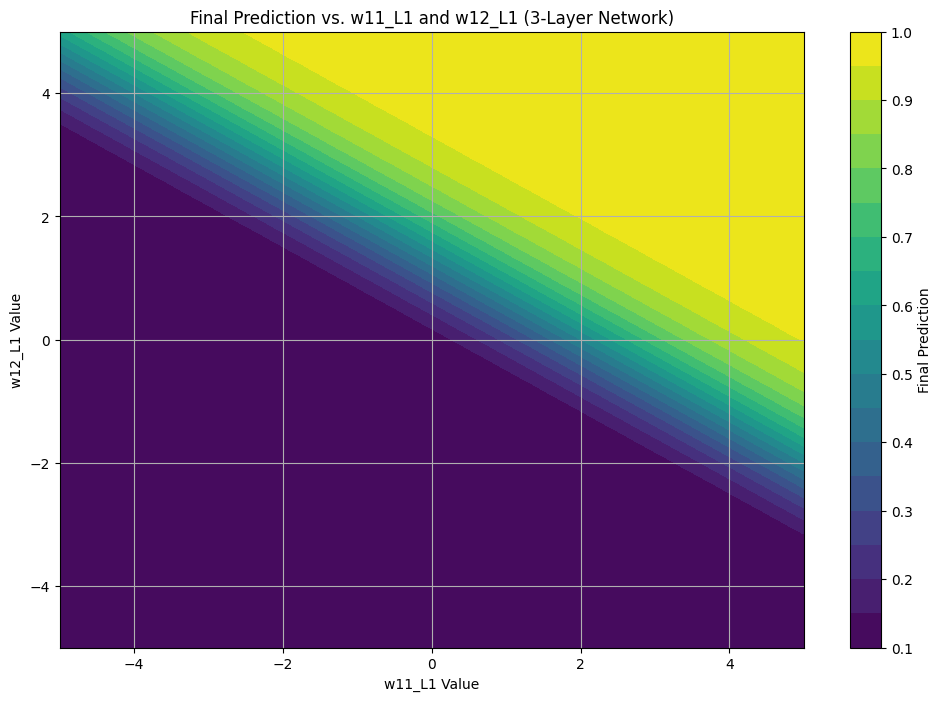

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Given Inputs (same as before)
x1_viz = 2
x2_viz = 3
network_inputs_viz = [x1_viz, x2_viz]

# --- Define weights and biases for a 3-layer network ---
# This will be: Input -> Hidden Layer 1 -> Hidden Layer 2 -> Output Layer

# Hidden Layer 1 (2 neurons) - Varying w11_l1 and w12_l1 for visualization
# Other weights are kept constant for this visualization
b1_l1_viz = 1
b21_l1_viz, b22_l1_viz = -1, 3
b2_l1_viz = 0

# Hidden Layer 2 (1 neuron for simplicity)
w11_l2_viz, b1_l2_viz = 0.5, -0.5

# Output Layer (takes input from Layer 2 activations)
wo1_final_viz, bo_final_viz = 1, -2

# Define the ranges for the weights we want to visualize
w11_l1_range = np.linspace(-5, 5, 50)
w12_l1_range = np.linspace(-5, 5, 50)

# Create a meshgrid for w11_l1 and w12_l1
W11_L1, W12_L1 = np.meshgrid(w11_l1_range, w12_l1_range)

# Initialize a 2D array to store predictions
predictions_3d_viz = np.zeros(W11_L1.shape)

# Iterate through each combination of w11_l1 and w12_l1
for i in range(W11_L1.shape[0]):
    for j in range(W11_L1.shape[1]):
        current_w11_l1 = W11_L1[i, j]
        current_w12_l1 = W12_L1[i, j]

        # Construct the hidden layers configuration dynamically
        hidden_layers_config_viz = [
            [ # First Hidden Layer
                ([current_w11_l1, current_w12_l1], b1_l1_viz), # Varying these two weights
                ([b21_l1_viz, b22_l1_viz], b2_l1_viz) # Other neuron in L1 (fixed)
            ],
            [ # Second Hidden Layer
                ([w11_l2_viz], b1_l2_viz) # Neuron in Layer 2 (fixed)
            ]
        ]

        output_layer_config_viz = ([wo1_final_viz], bo_final_viz)

        # Run the forward pass with the multi-layer generic function
        results_viz = run_forward_pass_multi_layer_generic(
            network_inputs_viz,
            hidden_layers_config_viz,
            output_layer_config_viz
        )
        predictions_3d_viz[i, j] = results_viz['prediction']

print("Predictions generated for a grid of w11_l1 and w12_l1 values for a 3-layer network.")

# --- Plotting the prediction landscape ---
plt.figure(figsize=(12, 8))
contour = plt.contourf(W11_L1, W12_L1, predictions_3d_viz, levels=20, cmap='viridis')
plt.colorbar(contour, label='Final Prediction')
plt.title('Final Prediction vs. w11_L1 and w12_L1 (3-Layer Network)')
plt.xlabel('w11_L1 Value')
plt.ylabel('w12_L1 Value')
plt.grid(True)
plt.show()

### Testing with Different Activation Functions: Tanh and Leaky ReLU

Now, let's explore how our generic multi-layer network performs with different activation functions for the hidden layers. We'll introduce `tanh` and `Leaky ReLU`.

This cell further enhances the flexibility of our generic multi-layer network by introducing the ability to use **different activation functions for hidden layers**.
1.  **New Activation Functions:** `tanh(x)` (Hyperbolic Tangent) and `leaky_relu(x, alpha=0.01)` are defined, offering alternatives to ReLU.
    *   `tanh(x) = (e^x - e^-x) / (e^x + e^-x)`
    *   `LeakyReLU(x) = x` if `x > 0`, else `alpha * x`
2.  **`run_forward_pass_flexible_activation`:** This new function accepts the desired `hidden_activation_func` as an argument, allowing dynamic selection of activation types.
The cell then demonstrates forward passes through the same 3-layer network, first using `tanh` for all hidden layers, and then `leaky_relu`. By comparing the intermediate activations and final predictions, we can observe how the choice of activation function significantly impacts the network's internal signal processing and its ultimate output.

In [ ]:
import math

# Helper functions (copied for self-contained exercise)
def relu(x):
    return max(0, x)

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def tanh(x):
    return math.tanh(x)

def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x

def neuron(inputs, weights, bias):
    # Calculate the weighted sum of inputs plus bias
    z = sum(i * w for i, w in zip(inputs, weights)) + bias
    return z

# --- Flexible run_forward_pass_multi_layer_generic_with_activation function ---
def run_forward_pass_flexible_activation(inputs, hidden_layers_config, output_layer_config, hidden_activation_func):
    """Runs a complete forward pass through a generically structured network with multiple hidden layers,
    using a specified activation function for hidden layers.

    Args:
        inputs (list): List of input values.
        hidden_layers_config (list): Configuration for hidden layers.
        output_layer_config (tuple): Configuration for the output neuron.
        hidden_activation_func (function): The activation function to use for hidden layers (e.g., relu, tanh, leaky_relu).

    Returns:
        dict: Contains final prediction and intermediate values for all layers.
    """

    all_hidden_activations = []
    all_hidden_zs = []

    current_inputs = inputs

    for layer_index, layer_config in enumerate(hidden_layers_config):
        layer_activations = []
        layer_zs = []

        for neuron_index, (weights, bias) in enumerate(layer_config):
            z = neuron(current_inputs, weights, bias)
            h_activation = hidden_activation_func(z)
            layer_zs.append(z)
            layer_activations.append(h_activation)

        all_hidden_zs.append(layer_zs)
        all_hidden_activations.append(layer_activations)
        current_inputs = layer_activations # Output of current layer becomes input for the next layer

    output_weights, output_bias = output_layer_config
    z_output = neuron(current_inputs, output_weights, output_bias)
    prediction = sigmoid(z_output)

    return {
        'hidden_zs': all_hidden_zs,
        'hidden_activations': all_hidden_activations,
        'z_output': z_output,
        'prediction': prediction
    }

# --- Network configuration for demonstration (same as 3-layer viz) ---
x1_test = 2
x2_test = 3
network_inputs_test = [x1_test, x2_test]

b1_l1_test = 1
b21_l1_test, b22_l1_test = -1, 3
b2_l1_test = 0

w11_l2_test, b1_l2_test = 0.5, -0.5

wo1_final_test, bo_final_test = 1, -2

hidden_layers_config_test = [
    [ # First Hidden Layer Configuration
        ([1, 2], b1_l1_test), # Neuron 1 in Layer 1 (using original w11, w12 for simplicity)
        ([b21_l1_test, b22_l1_test], b2_l1_test)  # Neuron 2 in Layer 1
    ],
    [ # Second Hidden Layer Configuration
        ([w11_l2_test], b1_l2_test)          # Neuron 1 in Layer 2
    ]
]

output_layer_config_test = ([wo1_final_test], bo_final_test)

# --- Demonstrate with Tanh Activation ---
print('--- Forward Pass with Tanh Activation for Hidden Layers ---')
tanh_results = run_forward_pass_flexible_activation(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, tanh
)
print(f"Inputs: {network_inputs_test}")
print(f"Hidden Layer 1 (Tanh) Activations: {tanh_results['hidden_activations'][0]}")
print(f"Hidden Layer 2 (Tanh) Activations: {tanh_results['hidden_activations'][1]}")
print(f"Output z: {tanh_results['z_output']}")
print(f"Prediction with Tanh: {tanh_results['prediction']}")

print('\n' + '='*50 + '\n')

# --- Demonstrate with Leaky ReLU Activation ---
print('--- Forward Pass with Leaky ReLU Activation for Hidden Layers ---')
leaky_relu_results = run_forward_pass_flexible_activation(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, leaky_relu
)
print(f"Inputs: {network_inputs_test}")
print(f"Hidden Layer 1 (Leaky ReLU) Activations: {leaky_relu_results['hidden_activations'][0]}")
print(f"Hidden Layer 2 (Leaky ReLU) Activations: {leaky_relu_results['hidden_activations'][1]}")
print(f"Output z: {leaky_relu_results['z_output']}")
print(f"Prediction with Leaky ReLU: {leaky_relu_results['prediction']}")


--- Forward Pass with Tanh Activation for Hidden Layers ---
Inputs: [2, 3]
Hidden Layer 1 (Tanh) Activations: [0.999999969540041, 0.9999983369439447]
Hidden Layer 2 (Tanh) Activations: [-1.5229979499764568e-08]
Output z: -2.0000000152299795
Prediction with Tanh: 0.1192029204230674


--- Forward Pass with Leaky ReLU Activation for Hidden Layers ---
Inputs: [2, 3]
Hidden Layer 1 (Leaky ReLU) Activations: [9, 7]
Hidden Layer 2 (Leaky ReLU) Activations: [4.0]
Output z: 2.0
Prediction with Leaky ReLU: 0.8807970779778823


The `visualize_forward_pass_details` function is introduced to provide an in-depth, neuron-by-neuron trace of the forward pass for our flexible multi-layer network. This function meticulously prints:
*   The inputs received by each neuron.
*   The weights and bias applied.
*   The calculated `z` (pre-activation) value.
*   The final activated output.
This granular visualization is performed for the 3-layer network, demonstrating passes with both `tanh` and `leaky_relu` hidden activation functions. It offers an unparalleled view into how data is transformed at every single computational step within the network, making the propagation of values and the impact of different activation functions explicitly clear.

In [ ]:
def visualize_forward_pass_details(inputs, hidden_layers_config, output_layer_config, hidden_activation_func):
    """Visualizes the step-by-step input and output for each neuron in a multi-layer network."""

    # Run the forward pass to get all intermediate values
    results = run_forward_pass_flexible_activation(inputs, hidden_layers_config, output_layer_config, hidden_activation_func)

    print(f"\n--- Detailed Forward Pass Visualization (Hidden Activation: {hidden_activation_func.__name__}) ---")
    print(f"Initial Inputs: {inputs}")
    print("\n" + "="*40 + "\n")

    current_inputs_for_next_layer = list(inputs) # Convert tuple to list for consistency

    for layer_index, layer_config in enumerate(hidden_layers_config):
        print(f"--- Hidden Layer {layer_index + 1} ---")
        for neuron_index, (weights, bias) in enumerate(layer_config):
            z = neuron(current_inputs_for_next_layer, weights, bias)
            h_activation = hidden_activation_func(z)

            print(f"  Neuron {neuron_index + 1} (Layer {layer_index + 1}):")
            print(f"    Inputs: {current_inputs_for_next_layer}")
            print(f"    Weights: {weights}")
            print(f"    Bias: {bias}")
            print(f"    Pre-activation (z): sum(input * weight) + bias = {z}")
            print(f"    Activation ({hidden_activation_func.__name__}): {h_activation}\n")

        # Update current_inputs_for_next_layer for the next iteration
        # Use the activations from the results for accuracy, not re-calculating
        current_inputs_for_next_layer = results['hidden_activations'][layer_index]
        print("-"*30 + "\n")

    # Output Layer
    print("--- Output Layer ---")
    output_weights, output_bias = output_layer_config
    # The inputs to the output layer are the activations of the last hidden layer
    final_hidden_activations = results['hidden_activations'][-1]

    z_output = neuron(final_hidden_activations, output_weights, output_bias)
    prediction = sigmoid(z_output)

    print(f"  Inputs (from last hidden layer): {final_hidden_activations}")
    print(f"  Weights: {output_weights}")
    print(f"  Bias: {output_bias}")
    print(f"  Pre-activation (z): sum(input * weight) + bias = {z_output}")
    print(f"  Prediction (sigmoid): {prediction}\n")
    print("="*40)

# --- Demonstrate the visualization function ---

# Using the network configuration from the previous cell
x1_test = 2
x2_test = 3
network_inputs_test = [x1_test, x2_test]

b1_l1_test = 1
b21_l1_test, b22_l1_test = -1, 3
b2_l1_test = 0

w11_l2_test, b1_l2_test = 0.5, -0.5

wo1_final_test, bo_final_test = 1, -2

hidden_layers_config_test = [
    [ # First Hidden Layer Configuration
        ([1, 2], b1_l1_test),
        ([b21_l1_test, b22_l1_test], b2_l1_test)
    ],
    [ # Second Hidden Layer Configuration
        ([w11_l2_test], b1_l2_test)
    ]
]

output_layer_config_test = ([wo1_final_test], bo_final_test)

# Visualize with Tanh activation
visualize_forward_pass_details(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, tanh
)

# Visualize with Leaky ReLU activation
visualize_forward_pass_details(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, leaky_relu
)


--- Detailed Forward Pass Visualization (Hidden Activation: tanh) ---
Initial Inputs: [2, 3]


--- Hidden Layer 1 ---
  Neuron 1 (Layer 1):
    Inputs: [2, 3]
    Weights: [1, 2]
    Bias: 1
    Pre-activation (z): sum(input * weight) + bias = 9
    Activation (tanh): 0.999999969540041

  Neuron 2 (Layer 1):
    Inputs: [2, 3]
    Weights: [-1, 3]
    Bias: 0
    Pre-activation (z): sum(input * weight) + bias = 7
    Activation (tanh): 0.9999983369439447

------------------------------

--- Hidden Layer 2 ---
  Neuron 1 (Layer 2):
    Inputs: [0.999999969540041, 0.9999983369439447]
    Weights: [0.5]
    Bias: -0.5
    Pre-activation (z): sum(input * weight) + bias = -1.5229979499764568e-08
    Activation (tanh): -1.5229979499764568e-08

------------------------------

--- Output Layer ---
  Inputs (from last hidden layer): [-1.5229979499764568e-08]
  Weights: [1]
  Bias: -2
  Pre-activation (z): sum(input * weight) + bias = -2.0000000152299795
  Prediction (sigmoid): 0.11920292042306

### Dynamic Number of Input Neurons

The existing network functions (`neuron`, `run_forward_pass_flexible_activation`) are inherently capable of handling a dynamic number of input neurons. The crucial part is to ensure that the number of weights for each neuron in the **first hidden layer** matches the number of inputs provided to the network.

Below, I will add a simple function to generate a `hidden_layers_config` for the first layer dynamically, demonstrating how you can adapt the network architecture to different input sizes. We'll use a network with three inputs instead of two.

This cell addresses a crucial aspect of neural network design: **handling a dynamic number of input neurons**. Real-world datasets often have varying numbers of features.
1.  **`generate_dynamic_first_layer_config`:** A utility function is introduced to automatically create the weight and bias configurations for the *first hidden layer*, ensuring that each neuron in this layer receives the correct number of weights corresponding to the `num_inputs`.
2.  **Demonstration:** A network is configured with **three input features** (compared to the previous two). The `run_forward_pass_flexible_activation` and `visualize_forward_pass_details` functions are then used to perform and trace a forward pass through this network, employing Leaky ReLU activation. This clearly shows how our generic network can seamlessly adapt to different input dimensionalities, a fundamental requirement for practical applications.

In [ ]:
import random

def generate_dynamic_first_layer_config(num_inputs, num_neurons_in_layer, base_bias=0.0):
    """Generates a configuration for the first hidden layer with dynamic input weights.

    Args:
        num_inputs (int): The number of input features the network will receive.
        num_neurons_in_layer (int): The number of neurons in this first hidden layer.
        base_bias (float): A base bias value to use for neurons.

    Returns:
        list: A list of (weights, bias) tuples for the neurons in the first layer.
    """
    layer_config = []
    for _ in range(num_neurons_in_layer):
        # Generate random weights matching the number of inputs
        weights = [random.uniform(-1, 1) for _ in range(num_inputs)]
        # Use a simple bias for demonstration
        bias = base_bias + random.uniform(-0.5, 0.5)
        layer_config.append((weights, bias))
    return layer_config

# --- Demonstrate with 3 inputs ---

# New inputs: 3 features
new_network_inputs = [2, 3, 4]
num_input_features = len(new_network_inputs)

# Configure the first hidden layer to accept 3 inputs
# Let's say we still want 2 neurons in the first hidden layer
dynamic_first_hidden_layer_config = generate_dynamic_first_layer_config(num_input_features, 2)

# Re-use the second hidden layer and output layer configurations from previous examples
# (Note: if the number of neurons in the first hidden layer changes, the second layer's
# weights would also need to adapt, but for this demo we keep the count same (2 neurons in L1))

hidden_layers_config_dynamic = [
    dynamic_first_hidden_layer_config, # Our dynamically generated first layer
    [ # Second Hidden Layer (same as before, assuming 2 neurons in L1 output)
        ([w11_l2_test], b1_l2_test) # Needs 2 weights if L1 output 2 neurons. Let's adjust this for clarity.
    ]
]

# Correction: The `w11_l2_test` in the second hidden layer expects only one input.
# For the original setup, the first hidden layer had 2 neurons. The second hidden layer had 1 neuron that
# received input from the 2 neurons of the first hidden layer.
# So, ([w11_l2_test], b1_l2_test) would ideally be ([w_l2_n1_from_l1_n1, w_l2_n1_from_l1_n2], b1_l2_test)
# Let's define the second layer's weights to explicitly match the number of neurons in the first layer (which is 2).

# Redefine w11_l2_test to be a list of weights matching the number of neurons in the previous layer (2 in this case)
new_w_l2_n1 = [0.5, 0.3] # Two weights for the two neurons in the first hidden layer

hidden_layers_config_dynamic = [
    dynamic_first_hidden_layer_config,
    [ # Second Hidden Layer
        (new_w_l2_n1, b1_l2_test) # Neuron 1 in Layer 2, now with 2 weights
    ]
]

# Output layer configuration (same as before)
output_layer_config_dynamic = ([wo1_final_test], bo_final_test)

print('--- Forward Pass with Dynamic Input Neurons (3 Inputs, Leaky ReLU) ---')
dynamic_results = run_forward_pass_flexible_activation(
    new_network_inputs,
    hidden_layers_config_dynamic,
    output_layer_config_dynamic,
    leaky_relu
)

print(f"Inputs: {new_network_inputs}")
print(f"Hidden Layer 1 (Leaky ReLU) Activations: {dynamic_results['hidden_activations'][0]}")
print(f"Hidden Layer 2 (Leaky ReLU) Activations: {dynamic_results['hidden_activations'][1]}")
print(f"Output z: {dynamic_results['z_output']}")
print(f"Prediction with Leaky ReLU: {dynamic_results['prediction']}")

print('\n' + '='*50 + '\n')

print('--- Detailed Visualization with Dynamic Input Neurons (3 Inputs, Leaky ReLU) ---')
visualize_forward_pass_details(
    new_network_inputs,
    hidden_layers_config_dynamic,
    output_layer_config_dynamic,
    leaky_relu
)


--- Forward Pass with Dynamic Input Neurons (3 Inputs, Leaky ReLU) ---
Inputs: [2, 3, 4]
Hidden Layer 1 (Leaky ReLU) Activations: [0.6204932019803439, -0.031468151651313295]
Hidden Layer 2 (Leaky ReLU) Activations: [-0.0019919384450522203]
Output z: -2.001991938445052
Prediction with Leaky ReLU: 0.11899393985003275


--- Detailed Visualization with Dynamic Input Neurons (3 Inputs, Leaky ReLU) ---

--- Detailed Forward Pass Visualization (Hidden Activation: leaky_relu) ---
Initial Inputs: [2, 3, 4]


--- Hidden Layer 1 ---
  Neuron 1 (Layer 1):
    Inputs: [2, 3, 4]
    Weights: [0.29292446259669624, -0.283915271250917, 0.3456378882879838]
    Bias: -0.49616146261223293
    Pre-activation (z): sum(input * weight) + bias = 0.6204932019803439
    Activation (leaky_relu): 0.6204932019803439

  Neuron 2 (Layer 1):
    Inputs: [2, 3, 4]
    Weights: [-0.9290137728588346, -0.41192566661339614, -0.02148518133403532]
    Bias: 0.03293010576266964
    Pre-activation (z): sum(input * weight) + bi

Elevating our network's configurability, this cell introduces the highly versatile `generate_hidden_layer_config` function. Unlike its predecessor, this function can generate configuration for *any* hidden layer (not just the first one), taking `num_inputs_from_prev_layer` and `num_neurons_in_current_layer` as arguments.
This allows for the construction of arbitrarily deep and wide networks with ease. The demonstration showcases:
*   **Complex Architecture:** A network is dynamically built with **4 input features**, **two hidden layers** (containing 3 and 2 neurons respectively), and an output layer.
*   **Leaky ReLU Activation:** `LeakyReLU` is again used for hidden layers.
A forward pass is executed through this intricate, dynamically generated network, illustrating the full power of our modular design in creating and evaluating complex neural network topologies.

In [ ]:
def generate_hidden_layer_config(num_inputs_from_prev_layer, num_neurons_in_current_layer, base_bias=0.0):
    """Generates a configuration for a hidden layer with dynamic input weights.

    Args:
        num_inputs_from_prev_layer (int): The number of outputs from the previous layer.
        num_neurons_in_current_layer (int): The number of neurons in this current hidden layer.
        base_bias (float): A base bias value to use for neurons.

    Returns:
        list: A list of (weights, bias) tuples for the neurons in the current layer.
    """
    layer_config = []
    for _ in range(num_neurons_in_current_layer):
        # Generate random weights matching the number of inputs from the previous layer
        weights = [random.uniform(-1, 1) for _ in range(num_inputs_from_prev_layer)]
        # Use a simple bias for demonstration
        bias = base_bias + random.uniform(-0.5, 0.5)
        layer_config.append((weights, bias))
    return layer_config

# --- Demonstrate with a more complex, dynamically generated network ---

# 1. Define initial network inputs
complex_network_inputs = [1, 2, 3, 4] # 4 input features
num_initial_inputs = len(complex_network_inputs)

# 2. Configure Hidden Layer 1 (e.g., 3 neurons, receiving from 4 initial inputs)
num_neurons_h1 = 3
hidden_layer1_config = generate_hidden_layer_config(num_initial_inputs, num_neurons_h1)

# 3. Configure Hidden Layer 2 (e.g., 2 neurons, receiving from 3 neurons of H1)
num_neurons_h2 = 2
hidden_layer2_config = generate_hidden_layer_config(num_neurons_h1, num_neurons_h2)

# 4. Configure Output Layer (1 neuron, receiving from 2 neurons of H2)
num_neurons_output = 1
# For the output layer, we define its weights and bias directly for simplicity
output_layer_weights = [random.uniform(-1, 1) for _ in range(num_neurons_h2)]
output_layer_bias = random.uniform(-0.5, 0.5)
complex_output_layer_config = (output_layer_weights, output_layer_bias)

# Assemble the full hidden layers configuration
complex_hidden_layers_config = [
    hidden_layer1_config,
    hidden_layer2_config
]

print('--- Forward Pass with Complex Dynamically Configured Network (Leaky ReLU) ---')
complex_dynamic_results = run_forward_pass_flexible_activation(
    complex_network_inputs,
    complex_hidden_layers_config,
    complex_output_layer_config,
    leaky_relu
)

print(f"Inputs: {complex_network_inputs}")
for i, activations in enumerate(complex_dynamic_results['hidden_activations']):
    print(f"Hidden Layer {i+1} (Leaky ReLU) Activations: {activations}")
print(f"Output z: {complex_dynamic_results['z_output']}")
print(f"Prediction: {complex_dynamic_results['prediction']}")

--- Forward Pass with Complex Dynamically Configured Network (Leaky ReLU) ---
Inputs: [1, 2, 3, 4]
Hidden Layer 1 (Leaky ReLU) Activations: [-0.02079258450748993, -0.028210355970472688, 5.11004287834189]
Hidden Layer 2 (Leaky ReLU) Activations: [3.8765132361018217, -0.03937923280447023]
Output z: 3.618521345027606
Prediction: 0.9738783352175634


In [ ]:
complex_dynamic_results # This variable was generated by the previous cell, so it exists.

{'hidden_zs': [[-2.079258450748993, -2.8210355970472687, 5.11004287834189],
  [3.8765132361018217, -3.9379232804470226]],
 'hidden_activations': [[-0.02079258450748993,
   -0.028210355970472688,
   5.11004287834189],
  [3.8765132361018217, -0.03937923280447023]],
 'z_output': 3.618521345027606,
 'prediction': 0.9738783352175634}

This cell provides a raw display of the `complex_dynamic_results` dictionary, which was populated by the forward pass of the complex, dynamically configured network in the preceding cell. Examining this dictionary allows direct inspection of the computed `z` values, hidden layer activations, and the final prediction, offering a programmatic view of the network's internal state after processing the input.

--- Detailed Visualization with Complex Dynamically Configured Network (Leaky ReLU) ---

Here, the `visualize_forward_pass_details` function is put to its ultimate test, providing a comprehensive, step-by-step breakdown of the forward pass for the **complex dynamically configured network** (with 4 inputs and two hidden layers). This detailed trace is invaluable for:
*   **Verification:** Confirming the correct flow of data and calculations through each neuron and layer.
*   **Debugging:** Identifying any unexpected behavior in the network's internal computations.
*   **Deep Understanding:** Solidifying the comprehension of how abstract layer configurations translate into concrete numerical operations at every point in a multi-layered neural network.

In [ ]:
visualize_forward_pass_details(
    complex_network_inputs,
    complex_hidden_layers_config,
    complex_output_layer_config,
    leaky_relu
)


--- Detailed Forward Pass Visualization (Hidden Activation: leaky_relu) ---
Initial Inputs: [1, 2, 3, 4]


--- Hidden Layer 1 ---
  Neuron 1 (Layer 1):
    Inputs: [1, 2, 3, 4]
    Weights: [-0.8140097718807107, -0.26417238413571154, 0.4622867704913096, -0.43926768677319417]
    Bias: -0.36669347497801175
    Pre-activation (z): sum(input * weight) + bias = -2.079258450748993
    Activation (leaky_relu): -0.02079258450748993

  Neuron 2 (Layer 1):
    Inputs: [1, 2, 3, 4]
    Weights: [0.26262051261222474, 0.32907211629737, -0.7115057871222272, -0.37094829081853264]
    Bias: -0.12348981761342126
    Pre-activation (z): sum(input * weight) + bias = -2.8210355970472687
    Activation (leaky_relu): -0.028210355970472688

  Neuron 3 (Layer 1):
    Inputs: [1, 2, 3, 4]
    Weights: [0.6483547897322994, -0.5762540686300264, 0.5656391586105349, 0.9000114739827589]
    Bias: 0.31723285410700275
    Pre-activation (z): sum(input * weight) + bias = 5.11004287834189
    Activation (leaky_relu):

This cell marks a significant milestone: the refactoring of all previous modular functions into a cohesive **`NeuralNetwork` class**. This object-oriented approach encapsulates the entire network's logic and state, promoting reusability and maintainability.
Key features of this class include:
*   **Unified Activation Functions:** It internally holds instances of various activation function classes (e.g., `ReLU`, `Sigmoid`, `Tanh`, `LeakyReLU`, `Linear`, `ELU`, `Softplus`).
*   **`_neuron` Method:** A private helper for the core weighted sum + bias calculation.
*   **`configure_network` Method:** This is the heart of its flexibility, allowing dynamic network architecture definition. You specify `input_size`, a list of `hidden_layer_sizes`, and the desired `hidden_activation_obj` and `output_activation_obj`. It automatically creates `DenseLayer` objects with randomly initialized weights and biases.
*   **`forward` Method:** Executes a complete forward pass through the dynamically configured network, returning a structured `prediction_report`.
*   **`forward_trace` Method:** Provides the detailed, neuron-level breakdown of the forward pass, similar to `visualize_forward_pass_details`.
*   **`network_summary` and `visualize_architecture`:** Utility methods for inspecting the network's structure.
*   **`count_parameters`:** Calculates the total number of weights and biases.
*   **`save_parameters` and `load_parameters`:** Enables persistence of trained (or initialized) network states.

The cell then demonstrates the usage of this `NeuralNetwork` class with two comprehensive examples: a basic network using ReLU and a more complex multi-layer network employing Tanh activation, showcasing its configurability and functionality.

In [ ]:
import math
import random

# --- Core Activation Functions ---
def relu(x):
    """
    Rectified Linear Unit (ReLU) activation function.
    Returns 0 if x < 0, otherwise returns x.
    """
    return max(0, x)

def sigmoid(x):
    """
    Sigmoid activation function.
    Transforms any real-valued number to a value between 0 and 1.
    """
    return 1 / (1 + math.exp(-x))

def tanh(x):
    """
    Hyperbolic Tangent (Tanh) activation function.
    Transforms any real-valued number to a value between -1 and 1.
    """
    return math.tanh(x)

def leaky_relu(x, alpha=0.01):
    """
    Leaky Rectified Linear Unit (Leaky ReLU) activation function.
    Returns x if x > 0, otherwise returns alpha * x (a small slope for negative inputs).
    """
    return x if x > 0 else alpha * x

# --- Core Neuron Calculation ---
def neuron(inputs, weights, bias):
    """
    Calculates the weighted sum of inputs and adds a bias.

    Args:
        inputs (list): A list of input values.
        weights (list): A list of weights corresponding to each input.
        bias (float): The bias value for the neuron.

    Returns:
        float: The pre-activation (z) value of the neuron.
    """
    # Calculate the weighted sum of inputs plus bias
    z = sum(i * w for i, w in zip(inputs, weights)) + bias
    return z

# --- Derivative Functions for Backpropagation/Gradient Calculation ---
def d_relu(x):
    """
    Derivative of the ReLU activation function.
    Returns 1 if x > 0, otherwise returns 0.
    """
    return 1 if x > 0 else 0

def d_sigmoid(x):
    """
    Derivative of the Sigmoid activation function.
    Returns s * (1 - s), where s is the sigmoid of x.
    """
    s = sigmoid(x)
    return s * (1 - s)

# --- Specific 2-layer Forward Pass (for gradient calculation dependency) ---
def run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo):
    """
    Runs a complete forward pass through a simple 2-layer network and returns intermediate values.

    Args:
        x1 (float): First input.
        x2 (float): Second input.
        w11 (float): Weight connecting x1 to hidden neuron 1.
        w12 (float): Weight connecting x2 to hidden neuron 1.
        b1 (float): Bias for hidden neuron 1.
        w21 (float): Weight connecting x1 to hidden neuron 2.
        w22 (float): Weight connecting x2 to hidden neuron 2.
        b2 (float): Bias for hidden neuron 2.
        wo1 (float): Weight connecting hidden neuron 1 activation to output neuron.
        wo2 (float): Weight connecting hidden neuron 2 activation to output neuron.
        bo (float): Bias for output neuron.

    Returns:
        dict: A dictionary containing 'z' values and activations for hidden neurons and the output.
    """

    # Compute h1
    h1_inputs = [x1, x2]
    h1_weights = [w11, w12]
    z1 = neuron(h1_inputs, h1_weights, b1)
    h1_activation = relu(z1)

    # Compute h2
    h2_inputs = [x1, x2]
    h2_weights = [w21, w22]
    z2 = neuron(h2_inputs, h2_weights, b2)
    h2_activation = relu(z2)

    # Compute output neuron
    output_inputs = [h1_activation, h2_activation]
    output_weights = [wo1, wo2]
    z_output = neuron(output_inputs, output_weights, bo)
    prediction = sigmoid(z_output)

    return {
        'z1': z1,
        'h1_activation': h1_activation,
        'z2': z2,
        'h2_activation': h2_activation,
        'z_output': z_output,
        'prediction': prediction
    }

# --- Gradient Calculation for w11 (depends on run_forward_pass) ---
def calculate_gradient_w11(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo):
    """
    Calculates the gradient of the prediction with respect to weight w11 using the chain rule.

    Args:
        x1 (float): First input.
        x2 (float): Second input.
        w11 (float): Weight connecting x1 to hidden neuron 1.
        w12 (float): Weight connecting x2 to hidden neuron 1.
        b1 (float): Bias for hidden neuron 1.
        w21 (float): Weight connecting x1 to hidden neuron 2.
        w22 (float): Weight connecting x2 to hidden neuron 2.
        b2 (float): Bias for hidden neuron 2.
        wo1 (float): Weight connecting hidden neuron 1 activation to output neuron.
        wo2 (float): Weight connecting hidden neuron 2 activation to output neuron.
        bo (float): Bias for output neuron.

    Returns:
        float: The gradient of the prediction with respect to w11.
    """
    # Perform a forward pass to get all intermediate values
    forward_results = run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
    z1 = forward_results['z1']
    z_output = forward_results['z_output']

    # Calculate individual gradients using our derivative functions
    grad_sigmoid_z_output = d_sigmoid(z_output)
    grad_z_output_h1_activation = wo1
    grad_h1_activation_z1 = d_relu(z1)
    grad_z1_w11 = x1

    # Apply the chain rule
    gradient = grad_sigmoid_z_output * grad_z_output_h1_activation * grad_h1_activation_z1 * grad_z1_w11
    return gradient

# --- Generic Multi-Layer Forward Pass with Flexible Activation ---
def run_forward_pass_flexible_activation(inputs, hidden_layers_config, output_layer_config, hidden_activation_func):
    """
    Runs a complete forward pass through a generically structured network with multiple hidden layers,
    using a specified activation function for hidden layers.

    Args:
        inputs (list): List of input values.
        hidden_layers_config (list): Configuration for hidden layers.
        output_layer_config (tuple): Configuration for the output neuron.
        hidden_activation_func (function): The activation function to use for hidden layers (e.g., relu, tanh, leaky_relu).

    Returns:
        dict: Contains final prediction and intermediate values for all layers.
    """

    all_hidden_activations = []
    all_hidden_zs = []

    current_inputs = inputs

    for layer_index, layer_config in enumerate(hidden_layers_config):
        layer_activations = []
        layer_zs = []

        for neuron_index, (weights, bias) in enumerate(layer_config):
            z = neuron(current_inputs, weights, bias)
            h_activation = hidden_activation_func(z)
            layer_zs.append(z)
            layer_activations.append(h_activation)

        all_hidden_zs.append(layer_zs)
        all_hidden_activations.append(layer_activations)
        current_inputs = layer_activations # Output of current layer becomes input for the next layer

    output_weights, output_bias = output_layer_config
    z_output = neuron(current_inputs, output_weights, output_bias)
    prediction = sigmoid(z_output)

    return {
        'hidden_zs': all_hidden_zs,
        'hidden_activations': all_hidden_activations,
        'z_output': z_output,
        'prediction': prediction
    }

# --- Configuration Generation for Dynamic Layers ---
def generate_dynamic_first_layer_config(num_inputs, num_neurons_in_layer, base_bias=0.0):
    """
    Generates a configuration for the first hidden layer with dynamic input weights.

    Args:
        num_inputs (int): The number of input features the network will receive.
        num_neurons_in_layer (int): The number of neurons in this first hidden layer.
        base_bias (float): A base bias value to use for neurons.

    Returns:
        list: A list of (weights, bias) tuples for the neurons in the first layer.
    """
    layer_config = []
    for _ in range(num_neurons_in_layer):
        weights = [random.uniform(-1, 1) for _ in range(num_inputs)]
        bias = base_bias + random.uniform(-0.5, 0.5)
        layer_config.append((weights, bias))
    return layer_config

def generate_hidden_layer_config(num_inputs_from_prev_layer, num_neurons_in_current_layer, base_bias=0.0):
    """
    Generates a configuration for a hidden layer with dynamic input weights.

    Args:
        num_inputs_from_prev_layer (int): The number of outputs from the previous layer.
        num_neurons_in_current_layer (int): The number of neurons in this current hidden layer.
        base_bias (float): A base bias value to use for neurons.

    Returns:
        list: A list of (weights, bias) tuples for the neurons in the current layer.
    """
    layer_config = []
    for _ in range(num_neurons_in_current_layer):
        weights = [random.uniform(-1, 1) for _ in range(num_inputs_from_prev_layer)]
        bias = base_bias + random.uniform(-0.5, 0.5)
        layer_config.append((weights, bias))
    return layer_config

# --- Visualization Function ---
def visualize_forward_pass_details(inputs, hidden_layers_config, output_layer_config, hidden_activation_func):
    """
    Visualizes the step-by-step input and output for each neuron in a multi-layer network.

    Args:
        inputs (list): The initial input values to the network.
        hidden_layers_config (list): Configuration for the hidden layers.
        output_layer_config (tuple): Configuration for the output neuron.
        hidden_activation_func (function): The activation function used for hidden layers.
    """

    results = run_forward_pass_flexible_activation(inputs, hidden_layers_config, output_layer_config, hidden_activation_func)

    print(f"\n--- Detailed Forward Pass Visualization (Hidden Activation: {hidden_activation_func.__name__}) ---")
    print(f"Initial Inputs: {inputs}")
    print("\n" + "="*40 + "\n")

    # Use the initial inputs to start the visualization process
    current_inputs_for_vis = list(inputs)

    for layer_index, layer_config in enumerate(hidden_layers_config):
        print(f"--- Hidden Layer {layer_index + 1} ---")
        for neuron_index, (weights, bias) in enumerate(layer_config):
            # Recalculate z and activation for printing details
            z = neuron(current_inputs_for_vis, weights, bias)
            h_activation = hidden_activation_func(z)

            print(f"  Neuron {neuron_index + 1} (Layer {layer_index + 1}):")
            print(f"    Inputs: {current_inputs_for_vis}")
            print(f"    Weights: {weights}")
            print(f"    Bias: {bias}")
            print(f"    Pre-activation (z): sum(input * weight) + bias = {z}")
            print(f"    Activation ({hidden_activation_func.__name__}): {h_activation}\n")

        # Update current_inputs_for_vis for the next iteration to be the activations of the current layer
        current_inputs_for_vis = results['hidden_activations'][layer_index]
        print("-"*30 + "\n")

    # Output Layer
    print("--- Output Layer ---")
    output_weights, output_bias = output_layer_config
    final_hidden_activations = results['hidden_activations'][-1] # Inputs to output layer

    z_output = neuron(final_hidden_activations, output_weights, output_bias)
    prediction = sigmoid(z_output)

    print(f"  Inputs (from last hidden layer): {final_hidden_activations}")
    print(f"  Weights: {output_weights}")
    print(f"  Bias: {output_bias}")
    print(f"  Pre-activation (z): sum(input * weight) + bias = {z_output}")
    print(f"  Prediction (sigmoid): {prediction}\n")
    print("="*40)

def print_forward_pass_details(label, x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo):
    """
    Prints a step-by-step breakdown of the forward pass for a simple 2-layer network.

    Args:
        label (str): A descriptive label for the current case.
        x1 (float): First input.
        x2 (float): Second input.
        w11 (float): Weight connecting x1 to hidden neuron 1.
        w12 (float): Weight connecting x2 to hidden neuron 1.
        b1 (float): Bias for hidden neuron 1.
        w21 (float): Weight connecting x1 to hidden neuron 2.
        w22 (float): Weight connecting x2 to hidden neuron 2.
        b2 (float): Bias for hidden neuron 2.
        wo1 (float): Weight connecting hidden neuron 1 activation to output neuron.
        wo2 (float): Weight connecting hidden neuron 2 activation to output neuron.
        bo (float): Bias for output neuron.
    """
    print(f"\n--- {label}: w11={w11}, w12={w12} ---")
    results = run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo)

    # Input layer
    print(f"Inputs: x1={x1}, x2={x2}")

    # Hidden layer 1
    print(f"\n--- Hidden Neuron 1 (h1) ---")
    print(f"  z1 = (x1 * w11) + (x2 * w12) + b1")
    print(f"     = ({x1} * {w11}) + ({x2} * {w12}) + {b1}")
    print(f"     = {results['z1']}")
    print(f"  h1_activation = relu(z1) = relu({results['z1']}) = {results['h1_activation']}")

    # Hidden layer 2 (unchanged in these examples, using original w21, w22, b2)
    print(f"\n--- Hidden Neuron 2 (h2) ---")
    print(f"  z2 = (x1 * w21) + (x2 * w22) + b2")
    print(f"     = ({x1} * {w21}) + ({x2} * {w22}) + {b2}")
    print(f"     = {results['z2']}")
    print(f"  h2_activation = relu(z2) = relu({results['z2']}) = {results['h2_activation']}")

    # Output layer
    print(f"\n--- Output Neuron ---")
    print(f"  Input to output layer: h1_activation={results['h1_activation']}, h2_activation={results['h2_activation']}")
    print(f"  z_output = (h1_activation * wo1) + (h2_activation * wo2) + bo")
    print(f"           = ({results['h1_activation']} * {wo1}) + ({results['h2_activation']} * {wo2}) + {bo}")
    print(f"           = {results['z_output']}")
    print(f"  Prediction = sigmoid(z_output) = sigmoid({results['z_output']}) = {results['prediction']}")

--- Basic 2-Layer Forward Pass ---
Hidden neuron 1 z = 9
Hidden neuron 1 activation = 9


Hidden neuron 2 z = 7
Hidden neuron 2 activation = 7


Output z = 10.5
Prediction = 0.9999724643088853


--- Basic 2-Layer Forward Pass (using helper function) ---
Original prediction using run_forward_pass: 0.9999724643088853
Original h1_activation: 9
Original h2_activation: 7


--- Step-by-step Value Progression for Different w11 and w12 Combinations ---

--- Case 1 (Low Prediction): w11=-4, w12=-4 ---
Inputs: x1=2, x2=3

--- Hidden Neuron 1 (h1) ---
  z1 = (x1 * w11) + (x2 * w12) + b1
     = (2 * -4) + (3 * -4) + 1
     = -19
  h1_activation = relu(z1) = relu(-19) = 0

--- Hidden Neuron 2 (h2) ---
  z2 = (x1 * w21) + (x2 * w22) + b2
     = (2 * -1) + (3 * 3) + 0
     = 7
  h2_activation = relu(z2) = relu(7) = 7

--- Output Neuron ---
  Input to output layer: h1_activation=0, h2_activation=7
  z_output = (h1_activation * wo1) + (h2_activation * wo2) + bo
           = (0 * 1) + (7 * 0.5) + -2
   

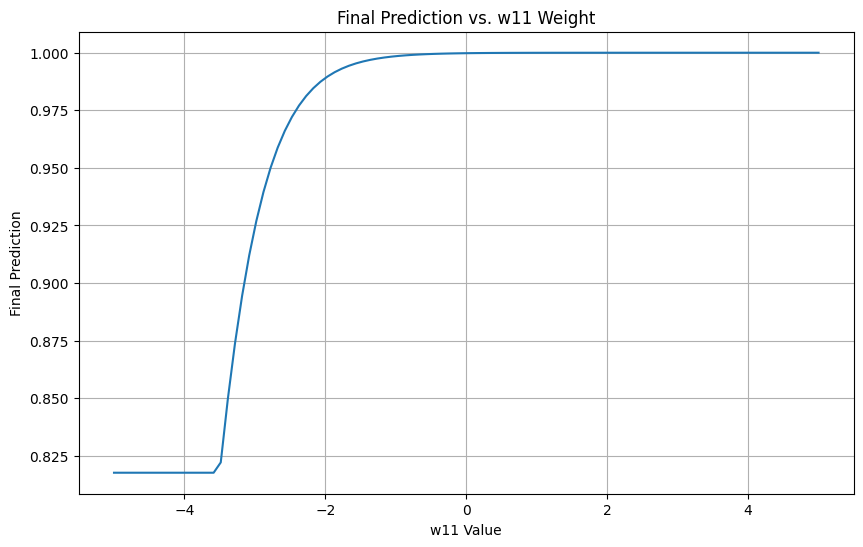



--- Visualizing Final Prediction vs. w11 and w12 Weights ---


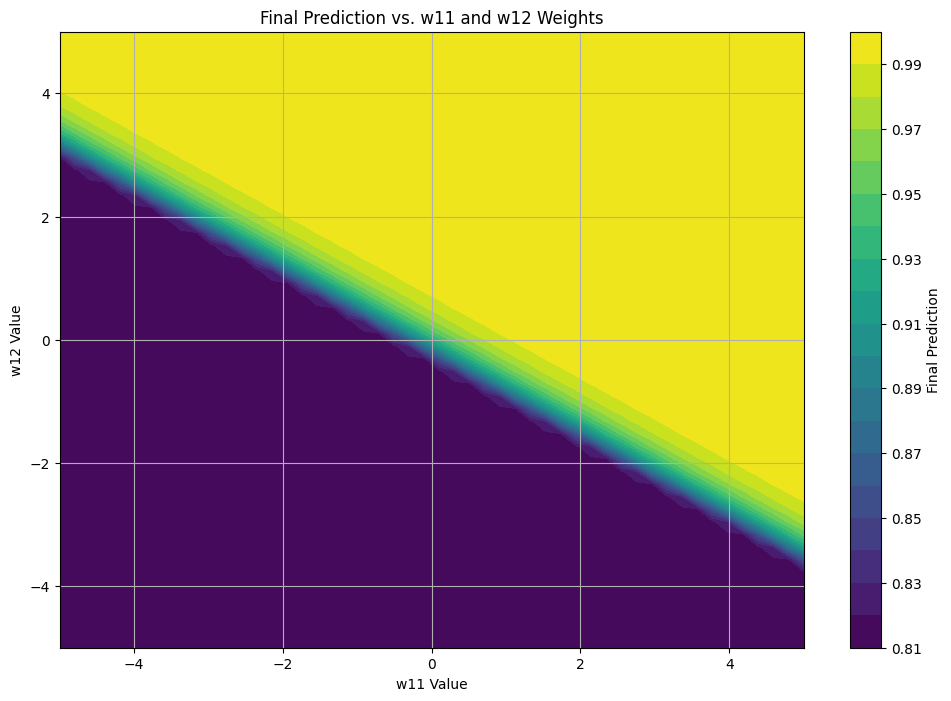



--- Visualizing the Gradient of w11 ---


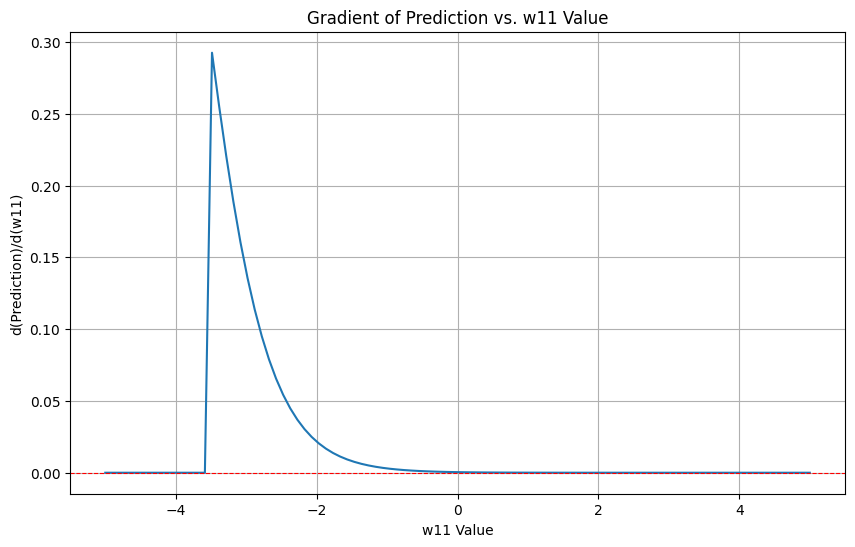



--- Simulating a Gradient Descent Update for w11 ---
Initial w11: 1
Gradient at initial w11: 5.506986580080658e-05
Learning Rate: 0.1
Calculated new w11: 0.9999944930134199

Prediction with old w11: 0.9999724643088853
Prediction with new w11: 0.9999724640056147


--- Multi-Layer Generic Network Example (2 Hidden Layers) ---
Inputs: [2, 3]

--- Hidden Layer 1 ---
  Neuron 1 z = 9
  Neuron 1 activation = 9
  Neuron 2 z = 7
  Neuron 2 activation = 7

--- Hidden Layer 2 ---
  Neuron 1 z = 4.0
  Neuron 1 activation = 4.0

--- Output Layer ---
  Output z = 2.0
  Prediction = 0.8807970779778823


--- Visualizing Prediction Landscape for a 3-Layer Architecture ---
Predictions generated for a grid of w11_l1 and w12_l1 values for a 3-layer network.


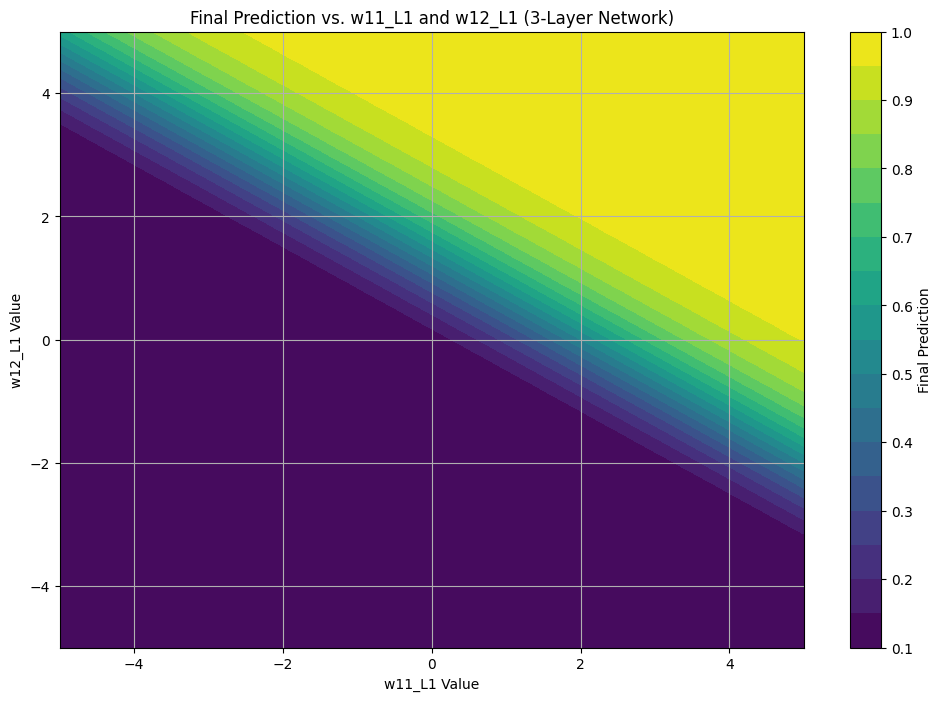



--- Testing with Different Activation Functions: Tanh and Leaky ReLU ---
--- Forward Pass with Tanh Activation for Hidden Layers ---
Inputs: [2, 3]
Hidden Layer 1 (Tanh) Activations: [0.999999969540041, 0.9999983369439447]
Hidden Layer 2 (Tanh) Activations: [-1.5229979499764568e-08]
Output z: -2.0000000152299795
Prediction with Tanh: 0.1192029204230674


--- Forward Pass with Leaky ReLU Activation for Hidden Layers ---
Inputs: [2, 3]
Hidden Layer 1 (Leaky ReLU) Activations: [9, 7]
Hidden Layer 2 (Leaky ReLU) Activations: [4.0]
Output z: 2.0
Prediction with Leaky ReLU: 0.8807970779778823


--- Detailed Visualization with Tanh and Leaky ReLU activations ---

--- Detailed Forward Pass Visualization (Hidden Activation: tanh) ---
Initial Inputs: [2, 3]


--- Hidden Layer 1 ---
  Neuron 1 (Layer 1):
    Inputs: [2, 3]
    Weights: [1, 2]
    Bias: 1
    Pre-activation (z): sum(input * weight) + bias = 9
    Activation (tanh): 0.999999969540041

  Neuron 2 (Layer 1):
    Inputs: [2, 3]
    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Demonstration 1: Basic 2-layer forward pass ---
# Given Inputs
x1 = 2
x2 = 3

# Hidden layer weights and biases
# h1
w11 = 1
w12 = 2
b1 = 1

# h2
w21 = -1
w22 = 3
b2 = 0

# Output layer weights and bias
wo1 = 1
wo2 = 0.5
bo = -2

print('--- Basic 2-Layer Forward Pass ---')
# Compute h1
h1_inputs = [x1, x2]
h1_weights = [w11, w12]
z1_val = neuron(h1_inputs, h1_weights, b1)
h1_activation_val = relu(z1_val)
print(f"Hidden neuron 1 z = {z1_val}")
print(f"Hidden neuron 1 activation = {h1_activation_val}")

print("\n")

# Compute h2
h2_inputs = [x1, x2]
h2_weights = [w21, w22]
z2_val = neuron(h2_inputs, h2_weights, b2)
h2_activation_val = relu(z2_val)
print(f"Hidden neuron 2 z = {z2_val}")
print(f"Hidden neuron 2 activation = {h2_activation_val}")

print("\n")

# Compute output neuron
output_inputs = [h1_activation_val, h2_activation_val]
output_weights = [wo1, wo2]
z_output_val = neuron(output_inputs, output_weights, bo)
prediction_val = sigmoid(z_output_val)

print(f"Output z = {z_output_val}")
print(f"Prediction = {prediction_val}")

print('\n' + '='*50 + '\n')

# Demonstrate using the run_forward_pass function
print('--- Basic 2-Layer Forward Pass (using helper function) ---')
original_results = run_forward_pass(x1, x2, w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
print(f"Original prediction using run_forward_pass: {original_results['prediction']}")
print(f"Original h1_activation: {original_results['h1_activation']}")
print(f"Original h2_activation: {original_results['h2_activation']}")

print('\n' + '='*50 + '\n')

# --- Demonstration 2: Step-by-step Value Progression for Different w11 and w12 Combinations ---
print('--- Step-by-step Value Progression for Different w11 and w12 Combinations ---')
# Example 1: Low w11, Low w12 (expecting low prediction)
print_forward_pass_details("Case 1 (Low Prediction)", x1, x2, -4, -4, b1, w21, w22, b2, wo1, wo2, bo)

# Example 2: Mid-range w11, Mid-range w12 (expecting transition)
print_forward_pass_details("Case 2 (Transition)", x1, x2, 0, 0, b1, w21, w22, b2, wo1, wo2, bo)

# Example 3: High w11, High w12 (expecting high prediction - saturation)
print_forward_pass_details("Case 3 (High Prediction)", x1, x2, 4, 4, b1, w21, w22, b2, wo1, wo2, bo)

print('\n' + '='*50 + '\n')

# --- Demonstration 3: Visualizing Final Prediction vs. w11 Weight ---
print('--- Visualizing Final Prediction vs. w11 Weight ---')
# Define the range for w11
w11_values_to_test = np.linspace(-5, 5, 100) # 100 values from -5 to 5

# List to store predictions
predictions_for_w11_range = []

# Iterate through each w11 value and run the forward pass
for current_w11 in w11_values_to_test:
    prediction_results = run_forward_pass(
        x1, x2,
        current_w11, w12, b1, # w11 is varied
        w21, w22, b2,
        wo1, wo2, bo
    )
    predictions_for_w11_range.append(prediction_results['prediction'])

plt.figure(figsize=(10, 6))
sns.lineplot(x=w11_values_to_test, y=predictions_for_w11_range)
plt.title('Final Prediction vs. w11 Weight')
plt.xlabel('w11 Value')
plt.ylabel('Final Prediction')
plt.grid(True)
plt.show()

print('\n' + '='*50 + '\n')

# --- Demonstration 4: Visualizing Final Prediction vs. w11 and w12 Weights ---
print('--- Visualizing Final Prediction vs. w11 and w12 Weights ---')
# Define the ranges for w11 and w12
w11_range = np.linspace(-5, 5, 50)
w12_range = np.linspace(-5, 5, 50)

# Create a meshgrid for w11 and w12
W11, W12 = np.meshgrid(w11_range, w12_range)

# Initialize a 2D array to store predictions
predictions_2d = np.zeros(W11.shape)

# Iterate through each combination of w11 and w12
for i in range(W11.shape[0]):
    for j in range(W11.shape[1]):
        current_w11 = W11[i, j]
        current_w12 = W12[i, j]

        prediction_results = run_forward_pass(
            x1, x2,
            current_w11, current_w12, b1,
            w21, w22, b2,
            wo1, wo2, bo
        )
        predictions_2d[i, j] = prediction_results['prediction']

plt.figure(figsize=(12, 8))
contour = plt.contourf(W11, W12, predictions_2d, levels=20, cmap='viridis')
plt.colorbar(contour, label='Final Prediction')
plt.title('Final Prediction vs. w11 and w12 Weights')
plt.xlabel('w11 Value')
plt.ylabel('w12 Value')
plt.grid(True)
plt.show()

print('\n' + '='*50 + '\n')

# --- Demonstration 5: Visualizing the Gradient of w11 ---
print('--- Visualizing the Gradient of w11 ---')
# Define the range for w11 (same as before)
w11_values_for_gradient = np.linspace(-5, 5, 100)

# List to store gradients
gradients_w11 = []

# Iterate through each w11 value and calculate the gradient
for current_w11 in w11_values_for_gradient:
    gradient = calculate_gradient_w11(
        x1, x2,
        current_w11, w12, b1, # w11 is varied, others constant
        w21, w22, b2,
        wo1, wo2, bo
    )
    gradients_w11.append(gradient)

plt.figure(figsize=(10, 6))
sns.lineplot(x=w11_values_for_gradient, y=gradients_w11)
plt.title('Gradient of Prediction vs. w11 Value')
plt.xlabel('w11 Value')
plt.ylabel('d(Prediction)/d(w11)')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a line at y=0
plt.show()

print('\n' + '='*50 + '\n')

# --- Demonstration 6: Simulating a Gradient Descent Update for w11 ---
print('--- Simulating a Gradient Descent Update for w11 ---')
# Define a learning rate
learning_rate = 0.1

# Get the current w11 and its gradient
old_w11 = w11 # Using the global w11 variable from setup
gradient_at_old_w11 = calculate_gradient_w11(x1, x2, old_w11, w12, b1, w21, w22, b2, wo1, wo2, bo)

# Perform the gradient descent update
new_w11 = old_w11 - (learning_rate * gradient_at_old_w11)

# Calculate predictions before and after the update
old_prediction_results = run_forward_pass(x1, x2, old_w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
old_prediction = old_prediction_results['prediction']

new_prediction_results = run_forward_pass(x1, x2, new_w11, w12, b1, w21, w22, b2, wo1, wo2, bo)
new_prediction = new_prediction_results['prediction']

print(f"Initial w11: {old_w11}")
print(f"Gradient at initial w11: {gradient_at_old_w11}")
print(f"Learning Rate: {learning_rate}")
print(f"Calculated new w11: {new_w11}")
print(f"\nPrediction with old w11: {old_prediction}")
print(f"Prediction with new w11: {new_prediction}")

print('\n' + '='*50 + '\n')

# --- Demonstration 7: Generic Network with Arbitrary Number of Hidden Layers (using run_forward_pass_flexible_activation) ---
print('--- Multi-Layer Generic Network Example (2 Hidden Layers) ---')
# Given Inputs
x1_multi_layer = 2
x2_multi_layer = 3
network_inputs_multi_layer = [x1_multi_layer, x2_multi_layer]

# Define weights and biases for a two-hidden-layer network
# Layer 1 (2 neurons)
w11_l1, w12_l1, b1_l1 = 1, 2, 1
w21_l1, w22_l1, b2_l1 = -1, 3, 0

# Layer 2 (1 neuron for simplicity)
w11_l2, b1_l2 = 0.5, -0.5 # Takes inputs from Layer 1 activations

# Output Layer (takes input from Layer 2 activations)
wo1_final, bo_final = 1, -2

hidden_layers_configuration = [
    [ # First Hidden Layer Configuration
        ([w11_l1, w12_l1], b1_l1), # Neuron 1 in Layer 1
        ([w21_l1, w22_l1], b2_l1)  # Neuron 2 in Layer 1
    ],
    [ # Second Hidden Layer Configuration
        ([w11_l2], b1_l2)          # Neuron 1 in Layer 2 (inputs are outputs of Layer 1)
    ]
]

output_layer_configuration_final = ([wo1_final], bo_final)

multi_layer_results = run_forward_pass_flexible_activation(network_inputs_multi_layer, hidden_layers_configuration, output_layer_configuration_final, relu)

# Print results
print(f"Inputs: {network_inputs_multi_layer}")
print(f"\n--- Hidden Layer 1 ---")
print(f"  Neuron 1 z = {multi_layer_results['hidden_zs'][0][0]}")
print(f"  Neuron 1 activation = {multi_layer_results['hidden_activations'][0][0]}")
print(f"  Neuron 2 z = {multi_layer_results['hidden_zs'][0][1]}")
print(f"  Neuron 2 activation = {multi_layer_results['hidden_activations'][0][1]}")

print(f"\n--- Hidden Layer 2 ---")
print(f"  Neuron 1 z = {multi_layer_results['hidden_zs'][1][0]}")
print(f"  Neuron 1 activation = {multi_layer_results['hidden_activations'][1][0]}")

print(f"\n--- Output Layer ---")
print(f"  Output z = {multi_layer_results['z_output']}")
print(f"  Prediction = {multi_layer_results['prediction']}")

print('\n' + '='*50 + '\n')

# --- Demonstration 8: Visualizing Prediction Landscape for a 3-Layer Architecture ---
print('--- Visualizing Prediction Landscape for a 3-Layer Architecture ---')
# Given Inputs (same as before)
x1_viz = 2
x2_viz = 3
network_inputs_viz = [x1_viz, x2_viz]

# --- Define weights and biases for a 3-layer network ---
# This will be: Input -> Hidden Layer 1 -> Hidden Layer 2 -> Output Layer

# Hidden Layer 1 (2 neurons) - Varying w11_l1 and w12_l1 for visualization
# Other weights are kept constant for this visualization
b1_l1_viz = 1
b21_l1_viz, b22_l1_viz = -1, 3
b2_l1_viz = 0

# Hidden Layer 2 (1 neuron for simplicity)
w11_l2_viz, b1_l2_viz = 0.5, -0.5

# Output Layer (takes input from Layer 2 activations)
wo1_final_viz, bo_final_viz = 1, -2

# Define the ranges for the weights we want to visualize
w11_l1_range = np.linspace(-5, 5, 50)
w12_l1_range = np.linspace(-5, 5, 50)

# Create a meshgrid for w11_l1 and w12_l1
W11_L1, W12_L1 = np.meshgrid(w11_l1_range, w12_l1_range)

# Initialize a 2D array to store predictions
predictions_3d_viz = np.zeros(W11_L1.shape)

# Iterate through each combination of w11_l1 and w12_l1
for i in range(W11_L1.shape[0]):
    for j in range(W11_L1.shape[1]):
        current_w11_l1 = W11_L1[i, j]
        current_w12_l1 = W12_L1[i, j]

        # Construct the hidden layers configuration dynamically
        hidden_layers_config_viz = [
            [ # First Hidden Layer
                ([current_w11_l1, current_w12_l1], b1_l1_viz), # Varying these two weights
                ([b21_l1_viz, b22_l1_viz], b2_l1_viz) # Other neuron in L1 (fixed)
            ],
            [ # Second Hidden Layer
                ([w11_l2_viz], b1_l2_viz) # Neuron in Layer 2 (fixed)
            ]
        ]

        output_layer_config_viz = ([wo1_final_viz], bo_final_viz)

        # Run the forward pass with the multi-layer generic function
        results_viz = run_forward_pass_flexible_activation(
            network_inputs_viz,
            hidden_layers_config_viz,
            output_layer_config_viz,
            relu
        )
        predictions_3d_viz[i, j] = results_viz['prediction']

print("Predictions generated for a grid of w11_l1 and w12_l1 values for a 3-layer network.")

# --- Plotting the prediction landscape ---
plt.figure(figsize=(12, 8))
contour = plt.contourf(W11_L1, W12_L1, predictions_3d_viz, levels=20, cmap='viridis')
plt.colorbar(contour, label='Final Prediction')
plt.title('Final Prediction vs. w11_L1 and w12_L1 (3-Layer Network)')
plt.xlabel('w11_L1 Value')
plt.ylabel('w12_L1 Value')
plt.grid(True)
plt.show()

print('\n' + '='*50 + '\n')

# --- Demonstration 9: Testing with Different Activation Functions: Tanh and Leaky ReLU ---
print('--- Testing with Different Activation Functions: Tanh and Leaky ReLU ---')
# Network configuration for demonstration (same as 3-layer viz)
x1_test = 2
x2_test = 3
network_inputs_test = [x1_test, x2_test]

b1_l1_test = 1
b21_l1_test, b22_l1_test = -1, 3
b2_l1_test = 0

w11_l2_test, b1_l2_test = 0.5, -0.5

wo1_final_test, bo_final_test = 1, -2

hidden_layers_config_test = [
    [ # First Hidden Layer Configuration
        ([1, 2], b1_l1_test), # Neuron 1 in Layer 1 (using original w11, w12 for simplicity)
        ([b21_l1_test, b22_l1_test], b2_l1_test)  # Neuron 2 in Layer 1
    ],
    [ # Second Hidden Layer Configuration
        ([w11_l2_test], b1_l2_test)          # Neuron 1 in Layer 2
    ]
]

output_layer_config_test = ([wo1_final_test], bo_final_test)

# --- Demonstrate with Tanh Activation ---
print('--- Forward Pass with Tanh Activation for Hidden Layers ---')
tanh_results = run_forward_pass_flexible_activation(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, tanh
)
print(f"Inputs: {network_inputs_test}")
print(f"Hidden Layer 1 (Tanh) Activations: {tanh_results['hidden_activations'][0]}")
print(f"Hidden Layer 2 (Tanh) Activations: {tanh_results['hidden_activations'][1]}")
print(f"Output z: {tanh_results['z_output']}")
print(f"Prediction with Tanh: {tanh_results['prediction']}")

print('\n' + '='*50 + '\n')

# --- Demonstrate with Leaky ReLU Activation ---
print('--- Forward Pass with Leaky ReLU Activation for Hidden Layers ---')
leaky_relu_results = run_forward_pass_flexible_activation(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, leaky_relu
)
print(f"Inputs: {network_inputs_test}")
print(f"Hidden Layer 1 (Leaky ReLU) Activations: {leaky_relu_results['hidden_activations'][0]}")
print(f"Hidden Layer 2 (Leaky ReLU) Activations: {leaky_relu_results['hidden_activations'][1]}")
print(f"Output z: {leaky_relu_results['z_output']}")
print(f"Prediction with Leaky ReLU: {leaky_relu_results['prediction']}")

print('\n' + '='*50 + '\n')

# --- Demonstration 10: Detailed Visualization with Tanh and Leaky ReLU activations ---
print('--- Detailed Visualization with Tanh and Leaky ReLU activations ---')
# Visualize with Tanh activation
visualize_forward_pass_details(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, tanh
)

# Visualize with Leaky ReLU activation
visualize_forward_pass_details(
    network_inputs_test, hidden_layers_config_test, output_layer_config_test, leaky_relu
)

print('\n' + '='*50 + '\n')

# --- Demonstration 11: Dynamic Number of Input Neurons ---
print('--- Forward Pass with Dynamic Input Neurons (3 Inputs, Leaky ReLU) ---')
# New inputs: 3 features
new_network_inputs = [2, 3, 4]
num_input_features = len(new_network_inputs)

# Configure the first hidden layer to accept 3 inputs
# Let's say we still want 2 neurons in the first hidden layer
dynamic_first_hidden_layer_config = generate_dynamic_first_layer_config(num_input_features, 2)

# Redefine new_w_l2_n1 to be a list of weights matching the number of neurons in the previous layer (2 in this case)
new_w_l2_n1 = [0.5, 0.3]

hidden_layers_config_dynamic = [
    dynamic_first_hidden_layer_config,
    [ # Second Hidden Layer
        (new_w_l2_n1, b1_l2_test) # Neuron 1 in Layer 2, now with 2 weights
    ]
]

# Output layer configuration (same as before)
output_layer_config_dynamic = ([wo1_final_test], bo_final_test)

dynamic_results = run_forward_pass_flexible_activation(
    new_network_inputs,
    hidden_layers_config_dynamic,
    output_layer_config_dynamic,
    leaky_relu
)

print(f"Inputs: {new_network_inputs}")
print(f"Hidden Layer 1 (Leaky ReLU) Activations: {dynamic_results['hidden_activations'][0]}")
print(f"Hidden Layer 2 (Leaky ReLU) Activations: {dynamic_results['hidden_activations'][1]}")
print(f"Output z: {dynamic_results['z_output']}")
print(f"Prediction with Leaky ReLU: {dynamic_results['prediction']}")

print('\n' + '='*50 + '\n')

print('--- Detailed Visualization with Dynamic Input Neurons (3 Inputs, Leaky ReLU) ---')
visualize_forward_pass_details(
    new_network_inputs,
    hidden_layers_config_dynamic,
    output_layer_config_dynamic,
    leaky_relu
)

print('\n' + '='*50 + '\n')

# --- Demonstration 12: More Complex Dynamically Configured Network (Multiple Layers) ---
print('--- Forward Pass with Complex Dynamically Configured Network (Leaky ReLU) ---')
# 1. Define initial network inputs
complex_network_inputs = [1, 2, 3, 4] # 4 input features
num_initial_inputs = len(complex_network_inputs)

# 2. Configure Hidden Layer 1 (e.g., 3 neurons, receiving from 4 initial inputs)
num_neurons_h1 = 3
hidden_layer1_config = generate_hidden_layer_config(num_initial_inputs, num_neurons_h1)

# 3. Configure Hidden Layer 2 (e.g., 2 neurons, receiving from 3 neurons of H1)
num_neurons_h2 = 2
hidden_layer2_config = generate_hidden_layer_config(num_neurons_h1, num_neurons_h2)

# 4. Configure Output Layer (1 neuron, receiving from 2 neurons of H2)
num_neurons_output = 1
# For the output layer, we define its weights and bias directly for simplicity
output_layer_weights = [random.uniform(-1, 1) for _ in range(num_neurons_h2)]
output_layer_bias = random.uniform(-0.5, 0.5)
complex_output_layer_config = (output_layer_weights, output_layer_bias)

# Assemble the full hidden layers configuration
complex_hidden_layers_config = [
    hidden_layer1_config,
    hidden_layer2_config
]

complex_dynamic_results = run_forward_pass_flexible_activation(
    complex_network_inputs,
    complex_hidden_layers_config,
    complex_output_layer_config,
    leaky_relu
)

print(f"Inputs: {complex_network_inputs}")
for i, activations in enumerate(complex_dynamic_results['hidden_activations']):
    print(f"Hidden Layer {i+1} (Leaky ReLU) Activations: {activations}")
print(f"Output z: {complex_dynamic_results['z_output']}")
print(f"Prediction: {complex_dynamic_results['prediction']}")

print('\n' + '='*50 + '\n')

print('--- Detailed Visualization with Complex Dynamically Configured Network (Leaky ReLU) ---')
visualize_forward_pass_details(
    complex_network_inputs,
    complex_hidden_layers_config,
    complex_output_layer_config,
    leaky_relu
)

In [ ]:
import math
import random # Needed for random weight initialization

class NeuralNetwork:
    def __init__(self):
        self.hidden_layers_config = [] # To store configuration of all hidden layers
        self.output_layer_config = ([], 0) # To store (weights, bias) for output layer
        self.hidden_activation_func = self.relu # Default hidden activation

    def relu(self, x):
        return max(0, x)

    def sigmoid(self, x):
        return 1 / (1 + math.exp(-x))

    def tanh(self, x):
        return math.tanh(x)

    def leaky_relu(self, x, alpha=0.01):
        return x if x > 0 else alpha * x

    def _neuron(self, inputs, weights, bias):
        # Helper method to calculate the weighted sum of inputs plus bias
        z = sum(i * w for i, w in zip(inputs, weights)) + bias
        return z

    def configure_network(self, input_size, hidden_layer_sizes, output_size=1, hidden_activation_func=None):
        """
        Configures the neural network's architecture with random weights and biases.

        Args:
            input_size (int): Number of input features.
            hidden_layer_sizes (list): A list of integers, where each integer is the number of
                                       neurons in a corresponding hidden layer.
            output_size (int): Number of output neurons (default 1 for this problem, hardcoded sigmoid).
            hidden_activation_func (function, optional): The activation function to use for hidden layers.
                                                          Defaults to self.relu if None.
        """
        if hidden_activation_func:
            self.hidden_activation_func = hidden_activation_func
        else:
            self.hidden_activation_func = self.relu # Ensure a default is set if not provided

        self.hidden_layers_config = []
        current_num_inputs = input_size

        # Configure hidden layers
        for layer_size in hidden_layer_sizes:
            layer_config = []
            for _ in range(layer_size):
                weights = [random.uniform(-1, 1) for _ in range(current_num_inputs)]
                bias = random.uniform(-0.5, 0.5)
                layer_config.append((weights, bias))
            self.hidden_layers_config.append(layer_config)
            current_num_inputs = layer_size # Output of current layer is input to next

        # Configure output layer (always 1 neuron for this binary classification setup)
        if output_size != 1:
            print("Warning: This network is designed for single output binary classification. Output size will be 1.")
        output_weights = [random.uniform(-1, 1) for _ in range(current_num_inputs)]
        output_bias = random.uniform(-0.5, 0.5)
        self.output_layer_config = (output_weights, output_bias)

    def forward(self, inputs):
        """
        Performs a forward pass through the configured neural network.

        Args:
            inputs (list): A list of input values.

        Returns:
            dict: A dictionary containing intermediate values and the final prediction.
                {
                    "hidden_zs": [[z_l1_n1, z_l1_n2], [z_l2_n1]], # List of lists for multiple layers
                    "hidden_activations": [[h_l1_n1, h_l1_n2], [h_l2_n1]], # List of lists
                    "output_z": z_output,
                    "prediction": prediction
                }
        """
        if not self.hidden_layers_config:
            raise ValueError("Network not configured. Call configure_network() first.")

        all_hidden_activations = []
        all_hidden_zs = []

        current_inputs = inputs

        for layer_config in self.hidden_layers_config:
            layer_activations = []
            layer_zs = []
            for weights, bias in layer_config:
                if len(current_inputs) != len(weights):
                    raise ValueError(f"Mismatch in input size and weights for a neuron in layer. Expected {len(weights)} inputs, got {len(current_inputs)}")
                z = self._neuron(current_inputs, weights, bias)
                h_activation = self.hidden_activation_func(z)
                layer_zs.append(z)
                layer_activations.append(h_activation)
            all_hidden_zs.append(layer_zs)
            all_hidden_activations.append(layer_activations)
            current_inputs = layer_activations # Output of current layer becomes input for the next

        output_weights, output_bias = self.output_layer_config
        if len(current_inputs) != len(output_weights):
            raise ValueError(f"Mismatch in input size and weights for output neuron. Expected {len(output_weights)} inputs, got {len(current_inputs)}")

        z_output = self._neuron(current_inputs, output_weights, output_bias)
        prediction = self.sigmoid(z_output) # Output layer always uses sigmoid

        return {
            "hidden_zs": all_hidden_zs,
            "hidden_activations": all_hidden_activations,
            "output_z": z_output,
            "prediction": prediction
        }


In [ ]:

# --- Example Usage for the refactored NeuralNetwork class: ---

# 1. Basic configuration: 2 inputs, 1 hidden layer with 2 neurons, 1 output neuron (using default ReLU)
net_relu = NeuralNetwork()
net_relu.configure_network(input_size=2, hidden_layer_sizes=[2], output_size=1)

# Test with inputs [2, 3]
test_inputs_relu = [2, 3]
prediction_results_relu = net_relu.forward(test_inputs_relu)

print("--- Generic Neural Network (ReLU) Demonstration ---")
print(f"Inputs: {test_inputs_relu}")
print(f"Configured Hidden Layers (Weights, Biases): {net_relu.hidden_layers_config}")
print(f"Configured Output Layer (Weights, Bias): {net_relu.output_layer_config}")
print(f"Hidden Activation Function: {net_relu.hidden_activation_func.__name__}")

print("\n--- Forward Pass Results ---")
for i, layer_zs in enumerate(prediction_results_relu['hidden_zs']):
    print(f"Hidden Layer {i+1} Z values: {layer_zs}")
    print(f"Hidden Layer {i+1} Activations: {prediction_results_relu['hidden_activations'][i]}")
print(f"Output Z value: {prediction_results_relu['output_z']}")
print(f"Final Prediction: {prediction_results_relu['prediction']}")

print("\n--- Raw Dictionary Output ---")
print(prediction_results_relu)

print("\n" + "="*50 + "\n")

# 2. Example with a different activation function (Tanh) and multiple hidden layers (3 inputs, 2 hidden layers)
net_tanh = NeuralNetwork()
net_tanh.configure_network(input_size=3, hidden_layer_sizes=[4, 2], output_size=1, hidden_activation_func=net_tanh.tanh)

test_inputs_tanh = [1, 0, -2] # Different inputs for variety
prediction_results_tanh = net_tanh.forward(test_inputs_tanh)

print("--- Generic Neural Network (Tanh, Multiple Layers) Demonstration ---")
print(f"Inputs: {test_inputs_tanh}")
print(f"Configured Hidden Layers (Weights, Biases): {net_tanh.hidden_layers_config}")
print(f"Configured Output Layer (Weights, Bias): {net_tanh.output_layer_config}")
print(f"Hidden Activation Function: {net_tanh.hidden_activation_func.__name__}")

print("\n--- Forward Pass Results ---")
for i, layer_zs in enumerate(prediction_results_tanh['hidden_zs']):
    print(f"Hidden Layer {i+1} Z values: {layer_zs}")
    print(f"Hidden Layer {i+1} Activations: {prediction_results_tanh['hidden_activations'][i]}")
print(f"Output Z value: {prediction_results_tanh['output_z']}")
print(f"Final Prediction: {prediction_results_tanh['prediction']}")

print("\n--- Raw Dictionary Output ---")
print(prediction_results_tanh)

--- Generic Neural Network (ReLU) Demonstration ---
Inputs: [2, 3]
Configured Hidden Layers (Weights, Biases): [[([-0.5165401055531145, -0.8250852468707832], -0.35727054619128484), ([0.9704852447201608, -0.5625618805504231], -0.3419024261944228)]]
Configured Output Layer (Weights, Bias): ([0.9108878478731754, -0.2645346098278858], -0.19915404214802268)
Hidden Activation Function: relu

--- Forward Pass Results ---
Hidden Layer 1 Z values: [-3.8656064979098637, -0.08861757840537043]
Hidden Layer 1 Activations: [0, 0]
Output Z value: -0.19915404214802268
Final Prediction: 0.45037540009087734

--- Raw Dictionary Output ---
{'hidden_zs': [[-3.8656064979098637, -0.08861757840537043]], 'hidden_activations': [[0, 0]], 'output_z': -0.19915404214802268, 'prediction': 0.45037540009087734}


--- Generic Neural Network (Tanh, Multiple Layers) Demonstration ---
Inputs: [1, 0, -2]
Configured Hidden Layers (Weights, Biases): [[([-0.20179141463244066, 0.7775073938817172, -0.4133793792736209], -0.04171

This comprehensive code cell serves as a consolidated demonstration hub for various aspects of the neural network implementation developed so far. It systematically illustrates:

*   **Basic 2-Layer Forward Pass:** Re-confirms the initial hardcoded network's forward computation.
*   **Step-by-step Value Progression:** Shows detailed neuron-level calculations for varying `w11` and `w12` combinations.
*   **Prediction Landscape Visualization (w11 & w12):** Plots how the final prediction changes with alterations to single (`w11`) and multiple (`w11`, `w12`) weights.
*   **Gradient Visualization & Descent:** Displays the gradient of `w11` and simulates a single step of gradient descent to update `w11`.
*   **Multi-Layer Generic Network:** Demonstrates the `run_forward_pass_flexible_activation` function with a two-hidden-layer network.
*   **Impact of Activation Functions:** Shows forward passes using `tanh` and `leaky_relu` for hidden layers, complete with detailed neuron-level traces.
*   **Dynamic Input Handling:** Illustrates how the network adapts to different numbers of input neurons, both for a simple case (3 inputs) and a more complex, dynamically generated multi-layer network (4 inputs).

This cell effectively ties together the modular components, showing their combined functionality and the network's increasing flexibility.

In [ ]:
# Removed duplicate code. The main NeuralNetwork and DenseLayer classes are defined in `yYrh7Y9qLeyz`.

In [ ]:
import math
import random # For random weight initialization
import numpy as np # For log and exp in Softplus
import json # Import json for saving/loading parameters

# 1. Activation Classes
class ReLU:
    def __call__(self, x):
        return max(0, x)
    def __str__(self):
        return "ReLU"

class Sigmoid:
    def __call__(self, x):
        return 1 / (1 + math.exp(-x))
    def __str__(self):
        return "Sigmoid"

class Tanh:
    def __call__(self, x):
        return math.tanh(x)
    def __str__(self):
        return "Tanh"

class LeakyReLU:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
    def __call__(self, x):
        return x if x > 0 else self.alpha * x
    def __str__(self):
        return f"LeakyReLU(alpha={self.alpha})"

class Linear:
    def __call__(self, x):
        return x
    def __str__(self):
        return "Linear"

class ELU:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    def __call__(self, x):
        return x if x >= 0 else self.alpha * (math.exp(x) - 1)
    def __str__(self):
        return f"ELU(alpha={self.alpha})"

class Softplus:
    def __call__(self, x):
        return np.log1p(np.exp(x)) # Use numpy.log1p for numerical stability
    def __str__(self):
        return "Softplus"

# 2. Layer Base Class
class Layer:
    def forward(self, inputs):
        raise NotImplementedError


class DenseLayer(Layer):
    """
A single dense (fully connected) layer in a neural network.

Attributes:
    num_inputs (int): Number of input features to this layer.
    num_neurons (int): Number of neurons in this layer.
    weights (list): A list of lists, where each inner list represents the
                    weights connecting inputs to a single neuron.
    biases (list): A list of bias values, one for each neuron.
    activation (object): The activation function object used by this layer's neurons.
    cache (dict): Stores intermediate values like 'z' (pre-activation) and 'activations'
                  for the current forward pass.
    trainable (bool): Indicates if the layer's parameters can be updated during training.
    """
    def __init__(self, num_inputs, num_neurons, activation):
        """
        Initializes a DenseLayer with random weights and biases.

        Args:
            num_inputs (int): The number of inputs this layer receives from the previous layer or input.
            num_neurons (int): The number of neurons in this layer.
            activation (object): The activation function object for this layer (e.g., ReLU(), Sigmoid()).
        """
        if num_inputs <= 0 or num_neurons <= 0:
            raise ValueError("Number of inputs and neurons must be positive.")

        self.num_inputs = num_inputs
        self.num_neurons = num_neurons
        self.activation = activation

        # Initialize weights and biases randomly
        self.weights = [[random.uniform(-1, 1) for _ in range(num_inputs)] for _ in range(num_neurons)]
        self.biases = [random.uniform(-0.5, 0.5) for _ in range(num_neurons)]

        # 10. Internal Cache
        self.cache = {
            "z": [], # Store pre-activation values
            "activations": [] # Store post-activation values
        }

        # 8. Layer Freezing
        self.trainable = True

    def forward(self, inputs):
        """
        Performs a forward pass through the layer.

        Args:
            inputs (list): A list of input values from the previous layer or input.

        Returns:
            list: A list of activated outputs from this layer.

        Raises:
            ValueError: If the number of inputs provided does not match the expected `num_inputs`.
        """
        if len(inputs) != self.num_inputs:
            raise ValueError(f"Input size mismatch for layer. Expected {self.num_inputs}, got {len(inputs)}.")

        # Clear cache for new forward pass
        self.cache['z'] = []
        self.cache['activations'] = []

        for i in range(self.num_neurons):
            weighted_sum = sum(w * x for w, x in zip(self.weights[i], inputs))
            z = weighted_sum + self.biases[i]
            self.cache['z'].append(z)
            self.cache['activations'].append(self.activation(z))

        return self.cache['activations']

    @property
    def num_parameters(self):
        """
        Calculates the total number of weights and biases in this layer.
        Returns:
            int: The total count of parameters.
        """
        return self.num_neurons * self.num_inputs + self.num_neurons


class NeuralNetwork:
    """
    A generic neural network capable of arbitrary hidden layers and activation functions.
    """
    def __init__(self):
        """
        Initializes an empty NeuralNetwork. Call `configure_network` to set up its architecture.
        """
        self.layers = []
        # Store activation function objects
        self.hidden_activation_obj = ReLU() # Default hidden activation
        self.output_activation_obj = Sigmoid() # Default output activation
        self.input_size = 0
        self.output_size = 0

    # --- Activation Functions (removed, now handled by classes) ---

    def configure_network(self, input_size, hidden_layer_sizes, output_size=1,
                          hidden_activation_obj=None, output_activation_obj=None):
        """
        Configures the neural network's architecture with `DenseLayer` objects.

        Args:
            input_size (int): Number of input features.
            hidden_layer_sizes (list): A list of integers, where each integer is the number of
                                       neurons in a corresponding hidden layer.
            output_size (int): Number of output neurons. Currently only supports 1 for this problem.
            hidden_activation_obj (object, optional): The activation function object to use for hidden layers.
                                                          Defaults to `ReLU()` if None.
            output_activation_obj (object, optional): The activation function object for the output layer.
                                                           Defaults to `Sigmoid()` if None.

        Raises:
            ValueError: If `input_size`, `hidden_layer_sizes` or `output_size` are invalid.
        """
        if not isinstance(input_size, int) or input_size <= 0:
            raise ValueError("Input size must be a positive integer.")
        if not isinstance(hidden_layer_sizes, list) or not all(isinstance(s, int) and s > 0 for s in hidden_layer_sizes):
            raise ValueError("Hidden layer sizes must be a list of positive integers.")
        if not isinstance(output_size, int) or output_size <= 0:
            raise ValueError("Output size must be a positive integer.")
        if output_size != 1: # Current limitation for this problem
            print("Warning: This network currently focuses on single output scenarios.")

        self.input_size = input_size
        self.output_size = output_size
        self.layers = []

        # Set activation function objects
        self.hidden_activation_obj = hidden_activation_obj if hidden_activation_obj else ReLU()
        self.output_activation_obj = output_activation_obj if output_activation_obj else Sigmoid()

        current_num_inputs = input_size

        # Create hidden layers
        for layer_size in hidden_layer_sizes:
            layer = DenseLayer(current_num_inputs, layer_size, self.hidden_activation_obj)
            self.layers.append(layer)
            current_num_inputs = layer_size

        # Create output layer
        output_layer = DenseLayer(current_num_inputs, output_size, self.output_activation_obj)
        self.layers.append(output_layer)

    def forward(self, inputs, target=None):
        """
        Performs a forward pass through the configured neural network.

        Args:
            inputs (list): A list of input values.
            target (float, optional): The target value, used for loss calculation if provided.

        Returns:
            dict: A dictionary containing the prediction report.
                {
                    "input": list, # Initial input to the network
                    "layers": [
                        {
                            "z": list, # Pre-activations for this layer
                            "activations": list # Activations for this layer
                        },
                        ...
                    ],
                    "prediction": list, # Activated output of the output layer
                    "loss": float # Calculated loss if target is provided
                }

        Raises:
            ValueError: If the network is not configured or input size mismatch occurs.
        """
        if not self.layers:
            raise ValueError("Network not configured. Call configure_network() first.")
        if len(inputs) != self.input_size:
            raise ValueError(f"Input size mismatch. Expected {self.input_size} features, got {len(inputs)}.")

        prediction_report = {
            "input": inputs,
            "layers": [],
            "prediction": None,
            "loss": None
        }

        current_layer_outputs = inputs

        # Process all layers (including output layer)
        for i, layer in enumerate(self.layers):
            current_layer_outputs = layer.forward(current_layer_outputs)
            layer_report = {
                "z": layer.cache['z'],
                "activations": layer.cache['activations']
            }
            prediction_report["layers"].append(layer_report)

        prediction_report["prediction"] = current_layer_outputs

        # Placeholder for loss calculation (when Loss classes are implemented)
        # if target is not None:
        #     loss_obj = MeanSquaredError() # Example, will be dynamic
        #     prediction_report["loss"] = loss_obj.compute(prediction_report["prediction"][0], target)

        return prediction_report

    def forward_trace(self, inputs, target=None):
        """
        Performs a forward pass and prints a detailed, neuron-level trace of the computation.

        Args:
            inputs (list): A list of input values.
            target (float, optional): The target value, used for loss calculation if provided.
        """
        print("\n--- Detailed Forward Pass Trace ---")
        print(f"Initial Inputs: {inputs}")
        print("="*50)

        prediction_report = self.forward(inputs, target) # Run the actual forward pass

        current_inputs_for_trace = list(inputs)

        for layer_idx, layer_report in enumerate(prediction_report['layers']):
            layer_obj = self.layers[layer_idx]
            layer_type = "Output Layer" if layer_idx == len(self.layers) - 1 else f"Hidden Layer {layer_idx + 1}"
            print(f"\n--- {layer_type} ({layer_obj.num_neurons} neurons, Activation: {layer_obj.activation.__str__()}) ---")

            for neuron_idx in range(layer_obj.num_neurons):
                # For tracing, reconstruct weighted sum + bias step
                weighted_sum = sum(w * x for w, x in zip(layer_obj.weights[neuron_idx], current_inputs_for_trace))
                z_val = weighted_sum + layer_obj.biases[neuron_idx]

                print(f"  Neuron {neuron_idx + 1}:")
                print(f"    Inputs: {current_inputs_for_trace}")
                print(f"    Weights: {layer_obj.weights[neuron_idx]}")
                print(f"    Bias: {layer_obj.biases[neuron_idx]}")
                print(f"    Weighted Sum + Bias (z): {z_val}")
                print(f"    Activation ({layer_obj.activation.__str__()}): {layer_report['activations'][neuron_idx]}")
            current_inputs_for_trace = layer_report['activations'] # Update inputs for the next layer
            print("-"*40)

        print(f"\nFinal Prediction: {prediction_report['prediction']}")
        if prediction_report['loss'] is not None:
            print(f"Loss: {prediction_report['loss']}")
        print("="*50)

    def network_summary(self):
        """
        Prints a summary of the network architecture, including input, hidden layers, and output.
        """
        print("\n--- Neural Network Summary ---")
        print(f"Input Layer: {self.input_size} neurons")

        if not self.layers:
            print("  (Network not configured)")
            return

        for i, layer in enumerate(self.layers):
            layer_type = "Output Layer" if i == len(self.layers) - 1 else f"Hidden Layer {i+1}"
            print(f"{layer_type}: {layer.num_neurons} neurons (Activation: {layer.activation.__str__()})")

        print("----------------------------")

    def count_parameters(self):
        """
        Calculates and prints the total number of weights and biases in the network.
        Returns:
            dict: A dictionary containing 'weights', 'biases', and 'total' parameter counts.
        """
        total_weights = 0
        total_biases = 0

        if not self.layers:
            print("Network not configured, no parameters to count.")
            return {'weights': 0, 'biases': 0, 'total': 0}

        for i, layer in enumerate(self.layers):
            total_weights += (layer.num_inputs * layer.num_neurons)
            total_biases += layer.num_neurons

        print("\n--- Parameter Count ---")
        print(f"Total Weights: {total_weights}")
        print(f"Total Biases: {total_biases}")
        print(f"Total Parameters: {total_weights + total_biases}")
        print("-----------------------")

        return {'weights': total_weights, 'biases': total_biases, 'total': total_weights + total_biases}

    def visualize_architecture(self):
        """
        Generates an ASCII visualization of the neural network architecture.
        """
        if not self.layers:
            print("Network not configured. Cannot visualize.")
            return

        print("\n--- Network Architecture Visualization ---")

        # Input Layer
        print(f"[Input Layer ({self.input_size})]")

        for i, layer in enumerate(self.layers):
            layer_label = f"Hidden Layer {i+1}" if i < len(self.layers) - 1 else "Output Layer"
            arrow_head = "    |\n    | \\" if i < len(self.layers) - 1 else "    |\n    V"
            print(arrow_head)
            print(f"    [{layer_label} ({layer.num_neurons} neurons)]")
            print(f"    (Activation: {layer.activation.__str__()})")
        print("----------------------------------------")

    def save_parameters(self, filepath):
        """
        Saves the network's weights and biases to a JSON file.

        Args:
            filepath (str): The path to the JSON file to save the parameters.
        """
        if not self.layers:
            print("Network not configured. No parameters to save.")
            return

        network_parameters = {
            "input_size": self.input_size,
            "output_size": self.output_size,
            "hidden_activation": self.hidden_activation_obj.__str__(),
            "output_activation": self.output_activation_obj.__str__(),
            "layers": []
        }

        for layer in self.layers:
            layer_params = {
                "num_inputs": layer.num_inputs,
                "num_neurons": layer.num_neurons,
                "weights": layer.weights,
                "biases": layer.biases
            }
            network_parameters["layers"].append(layer_params)

        with open(filepath, 'w') as f:
            json.dump(network_parameters, f, indent=4)
        print(f"Network parameters saved to {filepath}")

    def load_parameters(self, filepath):
        """
        Loads network parameters (weights and biases) from a JSON file.
        Note: This assumes the network architecture (number of layers, neurons per layer)
        is consistent with the saved parameters. Call configure_network() first if uncertain.

        Args:
            filepath (str): The path to the JSON file to load the parameters from.

        Raises:
            ValueError: If the loaded architecture doesn't match the current network configuration.
        """
        with open(filepath, 'r') as f:
            loaded_params = json.load(f)

        # Basic architecture validation
        if loaded_params['input_size'] != self.input_size or \
           loaded_params['output_size'] != self.output_size or \
           len(loaded_params['layers']) != len(self.layers):
            raise ValueError("Loaded network architecture does not match current configuration.")

        for i, loaded_layer_params in enumerate(loaded_params['layers']):
            current_layer = self.layers[i]

            if loaded_layer_params['num_inputs'] != current_layer.num_inputs or \
               loaded_layer_params['num_neurons'] != current_layer.num_neurons:
                raise ValueError(f"Layer {i} architecture mismatch. Expected {current_layer.num_inputs} inputs and {current_layer.num_neurons} neurons, but loaded {loaded_layer_params['num_inputs']} and {loaded_layer_params['num_neurons']}.")

            current_layer.weights = loaded_layer_params['weights']
            current_layer.biases = loaded_layer_params['biases']

        print(f"Network parameters loaded from {filepath}")

This cell vividly demonstrates the **persistence capabilities** of the `NeuralNetwork` class through its `save_parameters` and `load_parameters` methods.

Here's a breakdown of the demonstration:
1.  **Original Network Creation:** A `NeuralNetwork` instance (`net_original`) is created and configured with a specific architecture (2 inputs, 2 hidden layers with Tanh activation, 1 output with Sigmoid).
2.  **Initial Forward Pass:** A forward pass is executed with `net_original` using sample inputs, and its prediction is recorded.
3.  **Parameter Saving:** The `net_original.save_parameters()` method is invoked to serialize the network's weights and biases into a JSON file (`network_parameters.json`).
4.  **New Network Instance:** A completely new `NeuralNetwork` instance (`net_loaded`) is initialized.
5.  **Architecture Configuration:** Crucially, `net_loaded` is configured with the *exact same architecture* as `net_original`. This is a prerequisite for correctly loading parameters.
6.  **Parameter Loading:** The `net_loaded.load_parameters()` method reads the previously saved weights and biases from the JSON file and applies them to `net_loaded`.
7.  **Verification Pass:** A forward pass is performed with `net_loaded` using the *same sample inputs* as `net_original`.
8.  **Prediction Comparison:** The final step compares the predictions from `net_original` and `net_loaded`. The successful match of these predictions (to a high degree of precision) confirms that the saving and loading mechanisms accurately preserve the network's state, allowing for the reusability and deployment of trained models.

### Demonstrating Parameter Persistence: Save and Load

Now that the `NeuralNetwork` class includes `save_parameters` and `load_parameters` methods, let's create a network, save its initial state to a JSON file, and then load those parameters into a new network instance to verify the functionality.

In [ ]:
# 1. Create and configure a NeuralNetwork instance
net_original = NeuralNetwork()
net_original.configure_network(input_size=2, hidden_layer_sizes=[3, 2], hidden_activation_obj=Tanh(), output_activation_obj=Sigmoid())

print("--- Original Network Configuration ---")
net_original.network_summary()
print(f"Original network's first layer weights: {net_original.layers[0].weights[0]}")
print(f"Original network's output layer bias: {net_original.layers[-1].biases[0]}")

# Perform a forward pass to get an initial prediction
initial_inputs = [0.7, 0.3]
original_prediction_report = net_original.forward(initial_inputs)
print(f"Original network prediction for {initial_inputs}: {original_prediction_report['prediction'][0]:.4f}")

# 2. Define a filepath for saving parameters
filepath = 'network_parameters.json'

# 3. Save the parameters of the original network
net_original.save_parameters(filepath)

print("\n" + "="*50 + "\n")

# 4. Create a new, unconfigured NeuralNetwork instance
net_loaded = NeuralNetwork()

# 5. Configure the new network with the same architecture as the original
#    This step is crucial before loading to ensure layer counts and input/neuron counts match.
net_loaded.configure_network(input_size=2, hidden_layer_sizes=[3, 2], hidden_activation_obj=Tanh(), output_activation_obj=Sigmoid())

print("--- Loaded Network (before loading parameters) ---")
net_loaded.network_summary()
print(f"New network's first layer weights (before load): {net_loaded.layers[0].weights[0]}")
print(f"New network's output layer bias (before load): {net_loaded.layers[-1].biases[0]}")

# 6. Load the parameters into the new network
net_loaded.load_parameters(filepath)

print("\n--- Loaded Network (after loading parameters) ---")
net_loaded.network_summary()
print(f"Loaded network's first layer weights: {net_loaded.layers[0].weights[0]}")
print(f"Loaded network's output layer bias: {net_loaded.layers[-1].biases[0]}")

# 7. Perform a forward pass with the loaded network and compare predictions
loaded_prediction_report = net_loaded.forward(initial_inputs)
print(f"Loaded network prediction for {initial_inputs}: {loaded_prediction_report['prediction'][0]:.4f}")

# 8. Verify that predictions match
if abs(original_prediction_report['prediction'][0] - loaded_prediction_report['prediction'][0]) < 1e-9:
    print("\nSUCCESS: Original and loaded network predictions match!")
else:
    print("\nFAILURE: Predictions do NOT match.")


--- Original Network Configuration ---

--- Neural Network Summary ---
Input Layer: 2 neurons
Hidden Layer 1: 3 neurons (Activation: Tanh)
Hidden Layer 2: 2 neurons (Activation: Tanh)
Output Layer: 1 neurons (Activation: Sigmoid)
----------------------------
Original network's first layer weights: [-0.7223222256037534, -0.8007618438310908]
Original network's output layer bias: 0.08251721218943209
Original network prediction for [0.7, 0.3]: 0.6329
Network parameters saved to network_parameters.json


--- Loaded Network (before loading parameters) ---

--- Neural Network Summary ---
Input Layer: 2 neurons
Hidden Layer 1: 3 neurons (Activation: Tanh)
Hidden Layer 2: 2 neurons (Activation: Tanh)
Output Layer: 1 neurons (Activation: Sigmoid)
----------------------------
New network's first layer weights (before load): [-0.6577913387583323, -0.7498988681919609]
New network's output layer bias (before load): 0.35490214264621567
Network parameters loaded from network_parameters.json

--- Loade

In [ ]:
# Removed duplicate code. The main NeuralNetwork and DenseLayer classes are defined in `yYrh7Y9qLeyz`.

In [ ]:
# --- Demonstration of the new NeuralNetwork class with all new features ---

# 1. Instantiate the NeuralNetwork
net = NeuralNetwork()

print("\n--- Demonstration 1: Basic Network with ReLU hidden and Sigmoid output (defaults) ---")
# 2. Configure a basic network (2 inputs, 1 hidden layer of 3 neurons, 1 output)
net.configure_network(input_size=2, hidden_layer_sizes=[3])
# 3. Perform a forward pass
input_data_1 = [0.5, -0.2]
results_1 = net.forward(input_data_1)
print(f"Input: {input_data_1}")
print(f"Prediction: {results_1['prediction'][0]:.4f}")
# 4. Network Summary
net.network_summary()
# 5. Parameter Count
param_count_1 = net.count_parameters()
# 6. Visualize Architecture
net.visualize_architecture()

print("\n" + "="*50 + "\n")

print("--- Demonstration 2: Network with Tanh hidden and Linear output ---")
net.configure_network(input_size=4, hidden_layer_sizes=[5, 2],
                      hidden_activation_func=net.tanh, output_activation_func=net.linear)
input_data_2 = [1.0, -0.5, 0.8, -0.1]
results_2 = net.forward(input_data_2)
print(f"Input: {input_data_2}")
print(f"Prediction: {results_2['prediction'][0]:.4f}")
net.network_summary()
param_count_2 = net.count_parameters()
net.visualize_architecture()

print("\n" + "="*50 + "\n")

print("--- Demonstration 3: Network with ELU hidden and Softplus output ---")
net.configure_network(input_size=3, hidden_layer_sizes=[4, 2, 1],
                      hidden_activation_func=net.elu, output_activation_func=net.softplus)
input_data_3 = [0.1, 0.2, 0.3]
results_3 = net.forward(input_data_3)
print(f"Input: {input_data_3}")
print(f"Prediction: {results_3['prediction'][0]:.4f}")
net.network_summary()
param_count_3 = net.count_parameters()
net.visualize_architecture()

print("\n" + "="*50 + "\n")

print("--- Demonstration 4: Input Validation (expecting ValueError) ---")
try:
    net.configure_network(input_size=0, hidden_layer_sizes=[2], output_size=1)
except ValueError as e:
    print(f"Caught expected error: {e}")

try:
    net.configure_network(input_size=2, hidden_layer_sizes=[-1], output_size=1)
except ValueError as e:
    print(f"Caught expected error: {e}")

try:
    net.configure_network(input_size=2, hidden_layer_sizes=[2], output_size=0)
except ValueError as e:
    print(f"Caught expected error: {e}")


print("\n" + "="*50 + "\n")

print("--- Demonstration 5: Accessing internal layer details ---")
# Reconfigure for simple demonstration
net.configure_network(input_size=2, hidden_layer_sizes=[2], hidden_activation_func=net.relu)
input_data_5 = [1, 1]
_ = net.forward(input_data_5) # Run forward pass to populate layer._z and layer._activations

if net.layers:
    print(f"\nFirst hidden layer's pre-activations (z): {net.layers[0]._z}")
    print(f"First hidden layer's activations: {net.layers[0]._activations}")
    print(f"Output layer's pre-activations (z): {net.layers[-1]._z}")
    print(f"Output layer's activations (prediction): {net.layers[-1]._activations}")
net.visualize_architecture()


--- Demonstration 1: Basic Network with ReLU hidden and Sigmoid output (defaults) ---
Input: [0.5, -0.2]
Prediction: 0.4736

--- Neural Network Summary ---
Input Layer: 2 neurons
Hidden Layer 1: 3 neurons (Activation: relu)
Output Layer: 1 neurons (Activation: sigmoid)
----------------------------

--- Parameter Count ---
Total Weights: 9
Total Biases: 4
Total Parameters: 13
-----------------------

--- Network Architecture Visualization ---
[Input Layer (2)]
    |\n    | \
    [Hidden Layer 1 (3 neurons)]
    (Activation: relu)
    |\n    V
    [Output Layer (1 neurons)]
    (Activation: sigmoid)
----------------------------------------


--- Demonstration 2: Network with Tanh hidden and Linear output ---
Input: [1.0, -0.5, 0.8, -0.1]
Prediction: -0.1119

--- Neural Network Summary ---
Input Layer: 4 neurons
Hidden Layer 1: 5 neurons (Activation: tanh)
Hidden Layer 2: 2 neurons (Activation: tanh)
Output Layer: 1 neurons (Activation: linear)
----------------------------

--- Parameter

### Demonstration: Neural Network with 50 Hidden Layers

In [ ]:
# 1. Instantiate the NeuralNetwork
large_net = NeuralNetwork()

# 2. Define parameters for a large network
input_size_large = 10
num_hidden_layers = 50
hidden_layer_sizes_large = [random.randint(5, 10) for _ in range(num_hidden_layers)]

print(f"Configuring a network with {input_size_large} inputs and {len(hidden_layer_sizes_large)} hidden layers...")

# 3. Configure the large network with LeakyReLU activation
large_net.configure_network(
    input_size=input_size_large,
    hidden_layer_sizes=hidden_layer_sizes_large,
    hidden_activation_obj=LeakyReLU()
)

# 4. Generate sample input data
input_data_large = [random.uniform(-1, 1) for _ in range(input_size_large)]

print("Network configured. Performing forward pass...")

# 5. Perform a forward pass
results_large = large_net.forward(input_data_large)

print("\n--- Large Neural Network Demonstration ---")
print(f"Input: {input_data_large}")
print(f"Prediction: {results_large['prediction'][0]:.4f}")

# 6. Network Summary
large_net.network_summary()

# 7. Parameter Count
large_net.count_parameters()

# 8. Visualize Architecture (optional, might be too large for full display)
# large_net.visualize_architecture()

Configuring a network with 10 inputs and 50 hidden layers...
Network configured. Performing forward pass...

--- Large Neural Network Demonstration ---
Input: [0.971382959315755, 0.034875953232680335, -0.8462178916856538, -0.3425900378625999, -0.2433024104780448, 0.7219521407730749, 0.05315283816672145, 0.3956923599011899, -0.8448511251510462, 0.09899005629264357]
Prediction: 0.5863

--- Neural Network Summary ---
Input Layer: 10 neurons
Hidden Layer 1: 10 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 2: 5 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 3: 8 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 4: 8 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 5: 8 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 6: 8 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 7: 6 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 8: 9 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 9: 7 neurons (Activation: LeakyReLU(alpha=0.01))

{'weights': 2722, 'biases': 368, 'total': 3090}

### Demonstration: Neural Network with 1000 Hidden Layers

In [ ]:
# 1. Instantiate the NeuralNetwork
large_net_1000 = NeuralNetwork()

# 2. Define parameters for a very large network
input_size_1000 = 10
num_hidden_layers_1000 = 1000
hidden_layer_sizes_1000 = [random.randint(5, 10) for _ in range(num_hidden_layers_1000)]

print(f"Configuring a network with {input_size_1000} inputs and {len(hidden_layer_sizes_1000)} hidden layers...")

# 3. Configure the large network with LeakyReLU activation
large_net_1000.configure_network(
    input_size=input_size_1000,
    hidden_layer_sizes=hidden_layer_sizes_1000,
    hidden_activation_obj=LeakyReLU()
)

# 4. Generate sample input data
input_data_1000 = [random.uniform(-1, 1) for _ in range(input_size_1000)]

print("Network configured. Performing forward pass...")

# 5. Perform a forward pass
results_1000 = large_net_1000.forward(input_data_1000)

print("\n--- Very Large Neural Network Demonstration ---")
print(f"Input: {input_data_1000}")
print(f"Prediction: {results_1000['prediction'][0]:.4f}")

# 6. Network Summary
large_net_1000.network_summary()

# 7. Parameter Count
large_net_1000.count_parameters()

# 8. Visualize Architecture (optional, explicitly skipped due to very large size)
# large_net_1000.visualize_architecture()


Configuring a network with 10 inputs and 1000 hidden layers...
Network configured. Performing forward pass...

--- Very Large Neural Network Demonstration ---
Input: [-0.9809078038701979, -0.9880909352321612, 0.22033994367946086, -0.502299691515864, -0.1286421902374868, 0.8918844647220296, 0.8166677524797785, -0.5971344639507723, 0.5466249044495961, -0.6059001889228204]
Prediction: 0.2582

--- Neural Network Summary ---
Input Layer: 10 neurons
Hidden Layer 1: 10 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 2: 5 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 3: 6 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 4: 10 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 5: 9 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 6: 5 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 7: 8 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 8: 6 neurons (Activation: LeakyReLU(alpha=0.01))
Hidden Layer 9: 6 neurons (Activation: LeakyReLU(alpha

{'weights': 55545, 'biases': 7452, 'total': 62997}

In [ ]:
#  large_net_1000.visualize_architecture()
